# 04 — Análisis completo de Países (S4–S6)

Este cuaderno presenta el análisis final de los tres países
con mayor acumulado de turistas y excursionistas: El Salvador, Estados Unidos
y Guatemala. Aplica la misma plantilla de S0–S3: descomposición,
estacionariedad, selección razonada de órdenes, ARIMA/SARIMA, `auto_arima`,
cuatro modelos alternativos, diagnóstico residual y pronóstico de los 63
meses de prueba.

## Advertencia metodológica sobre `País`

De 2009 a 2022 la fuente identifica países individuales; desde 2023 reporta
27 agrupaciones de mercado. Las notas del archivo confirman que **El Salvador
y Estados Unidos continúan como mercados individuales comparables**. Guatemala
deja de aparecer como categoría individual, por lo que sus 42 ceros entre
enero de 2023 y junio de 2026 son un cambio de reporte y no una desaparición
real del retorno de residentes.

Además, el sistema depurado de 2023 excluye o reclasifica algunos movimientos.
Por ello, incluso en los mercados comparables, el salto 2022–2023 combina
cambio real y cambio metodológico.

## Metodología común

- Frecuencia mensual (`MS`) y período estacional 12.
- Entrenamiento: enero de 2009 a marzo de 2021 (147 meses).
- Prueba: abril de 2021 a junio de 2026 (63 meses), sin barajar.
- Se usa `log1p` porque S4 y S5 contienen cinco ceros pandémicos y S6 tiene
  ceros posteriores en prueba.
- ADF, KPSS y ACF/PACF determinan `d`; `auto_arima` se contrasta con órdenes
  manuales y no sustituye su explicación.
- Los residuos se revisan con ACF, Ljung-Box, Jarque-Bera y Q-Q.
- El mejor modelo se selecciona por RMSE de prueba, considerando también
  MAE, MAPE, AIC/BIC y los diagnósticos.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from modelado_s1_s2_s6 import ejecutar_modelado_paises

resultados, comparativo, tabla_maestra = ejecutar_modelado_paises(
    guardar=True,
    generar_figuras=True,
)
DIR_RESULTADOS = RAIZ / "data" / "processed" / "resultados"
DIR_IMG = RAIZ / "informe" / "img" / "final"
metricas = pd.read_csv(DIR_RESULTADOS / "metricas_paises.csv")
estacionariedad = pd.read_csv(
    DIR_RESULTADOS / "estacionariedad_paises.csv"
)

validacion = pd.DataFrame({
    "serie": list(resultados),
    "meses_total": [len(r["serie"]) for r in resultados.values()],
    "meses_train": [len(r["train"]) for r in resultados.values()],
    "meses_test": [len(r["test"]) for r in resultados.values()],
    "ceros_train": [
        r["resumen"]["ceros_train"] for r in resultados.values()
    ],
    "ceros_test": [
        r["resumen"]["ceros_test"] for r in resultados.values()
    ],
})
validacion

15:10:00 - cmdstanpy - INFO - Chain [1] start processing


15:10:00 - cmdstanpy - INFO - Chain [1] done processing


15:10:00 - cmdstanpy - INFO - Chain [1] start processing


15:10:01 - cmdstanpy - INFO - Chain [1] done processing


15:10:08 - cmdstanpy - INFO - Chain [1] start processing


15:10:08 - cmdstanpy - INFO - Chain [1] done processing


,serie,meses_total,meses_train,meses_test,ceros_train,ceros_test
0,S4_el_salvador,210,147,63,5,0
1,S5_estados_unidos,210,147,63,5,0
2,S6_guatemala,210,147,63,0,42


## S4 — El Salvador

S4 tiene fuerza de tendencia 0.783 y fuerza estacional 0.402. Los cinco ceros
de abril–agosto de 2020 impiden una descomposición multiplicativa directa, de
modo que se usa la aditiva y `log1p` para estabilizar la varianza. La
correlación media-desviación prepandemia baja de 0.805 a -0.629 después de la
transformación.

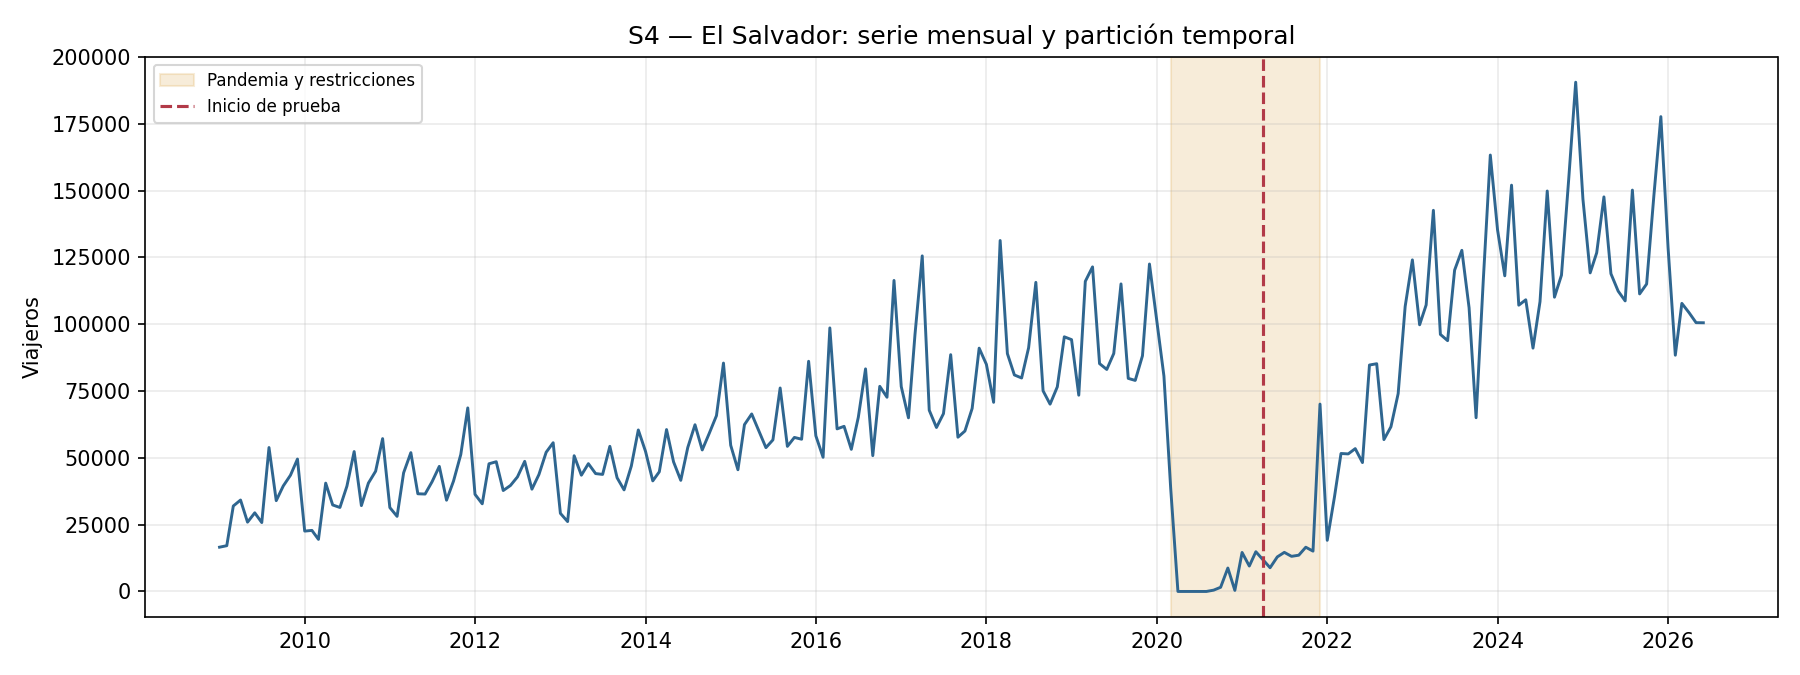

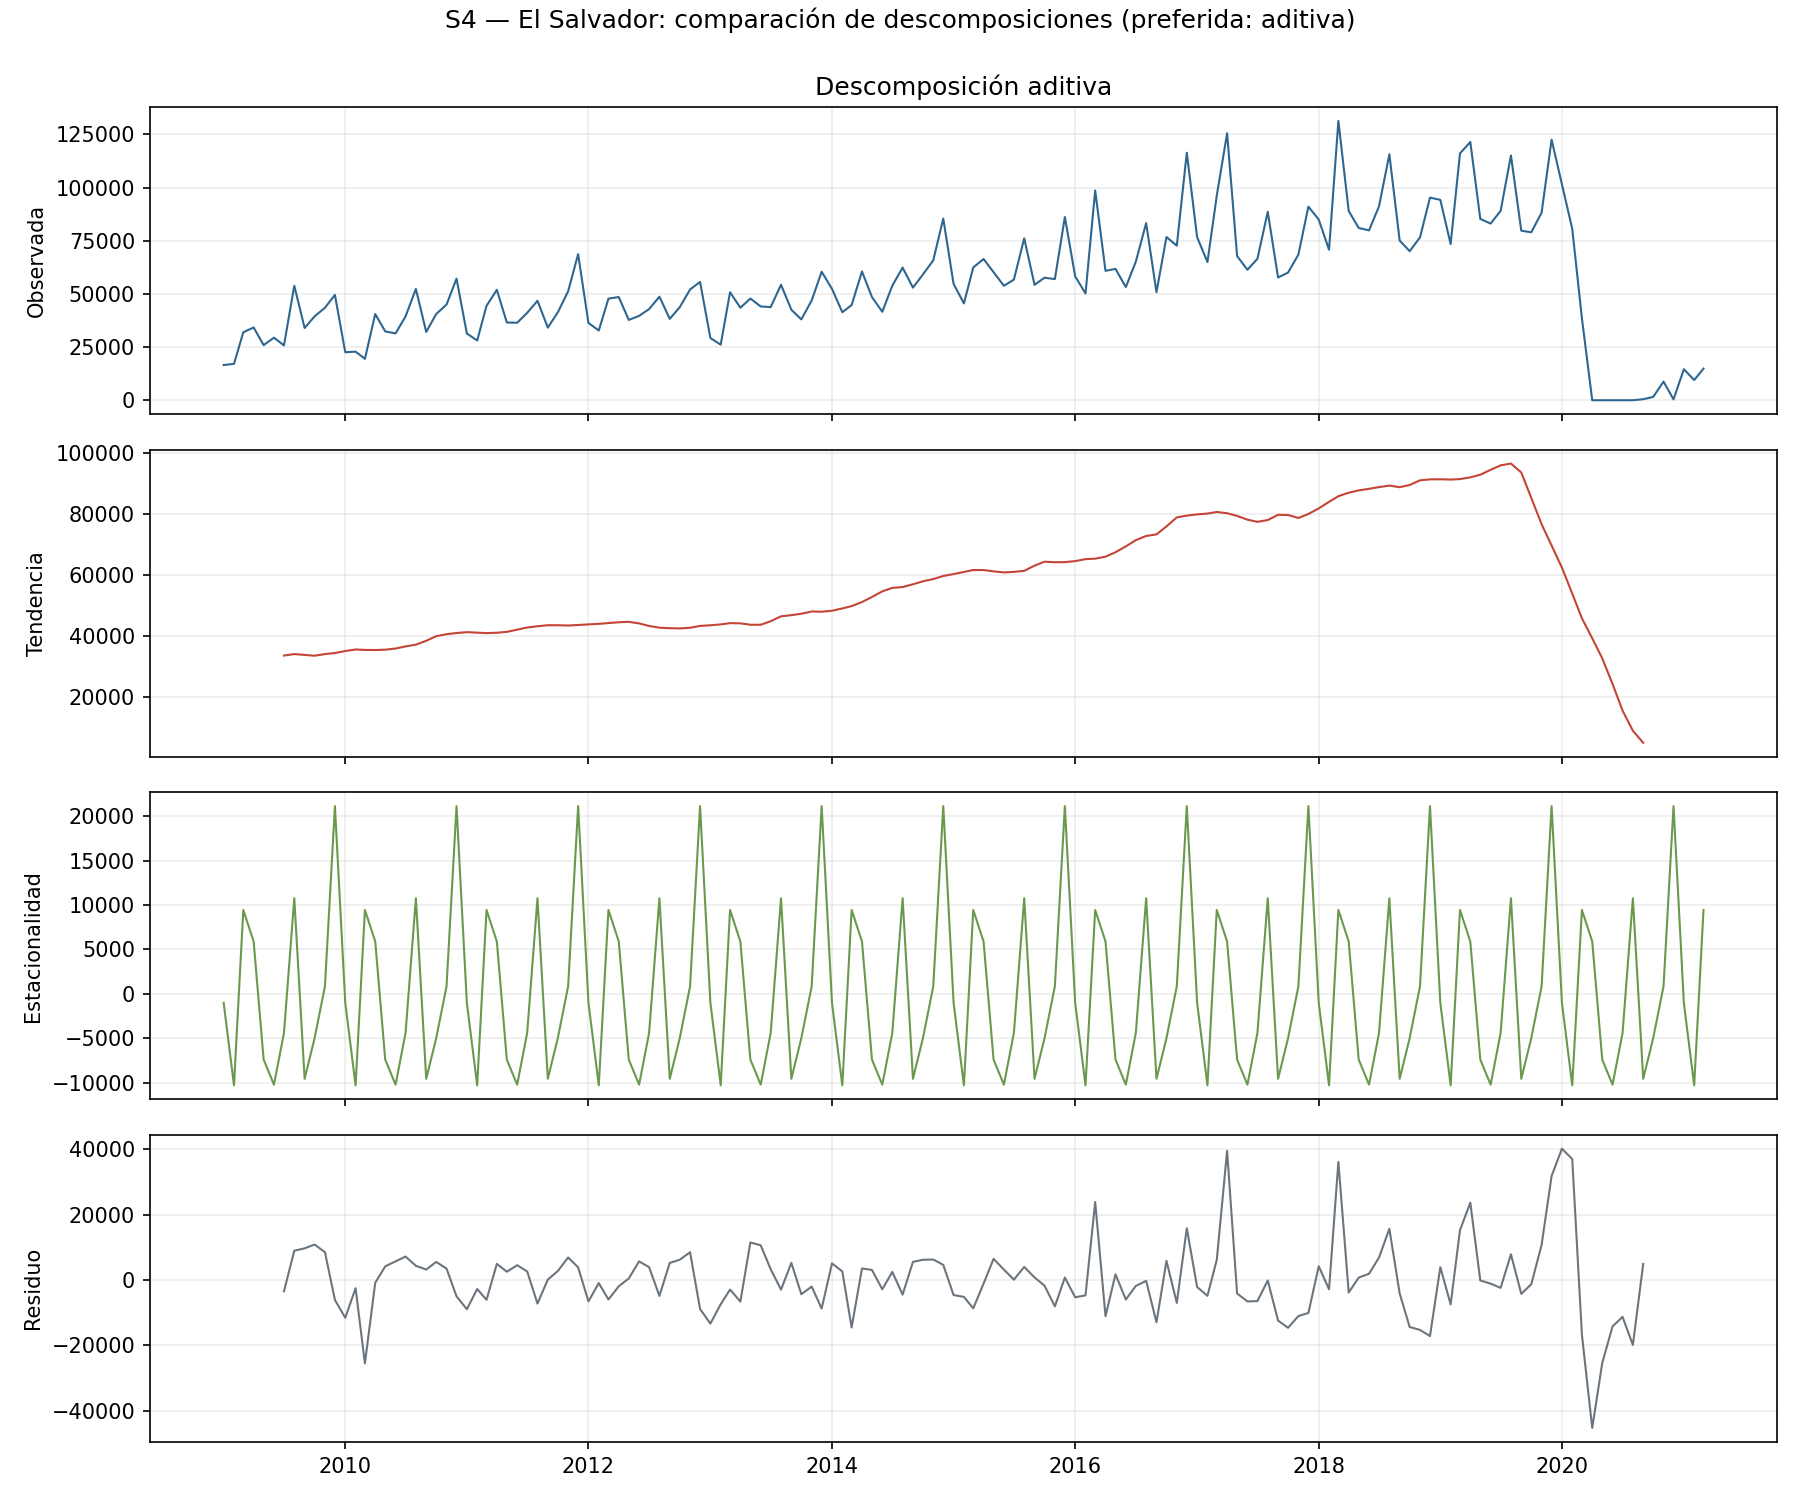

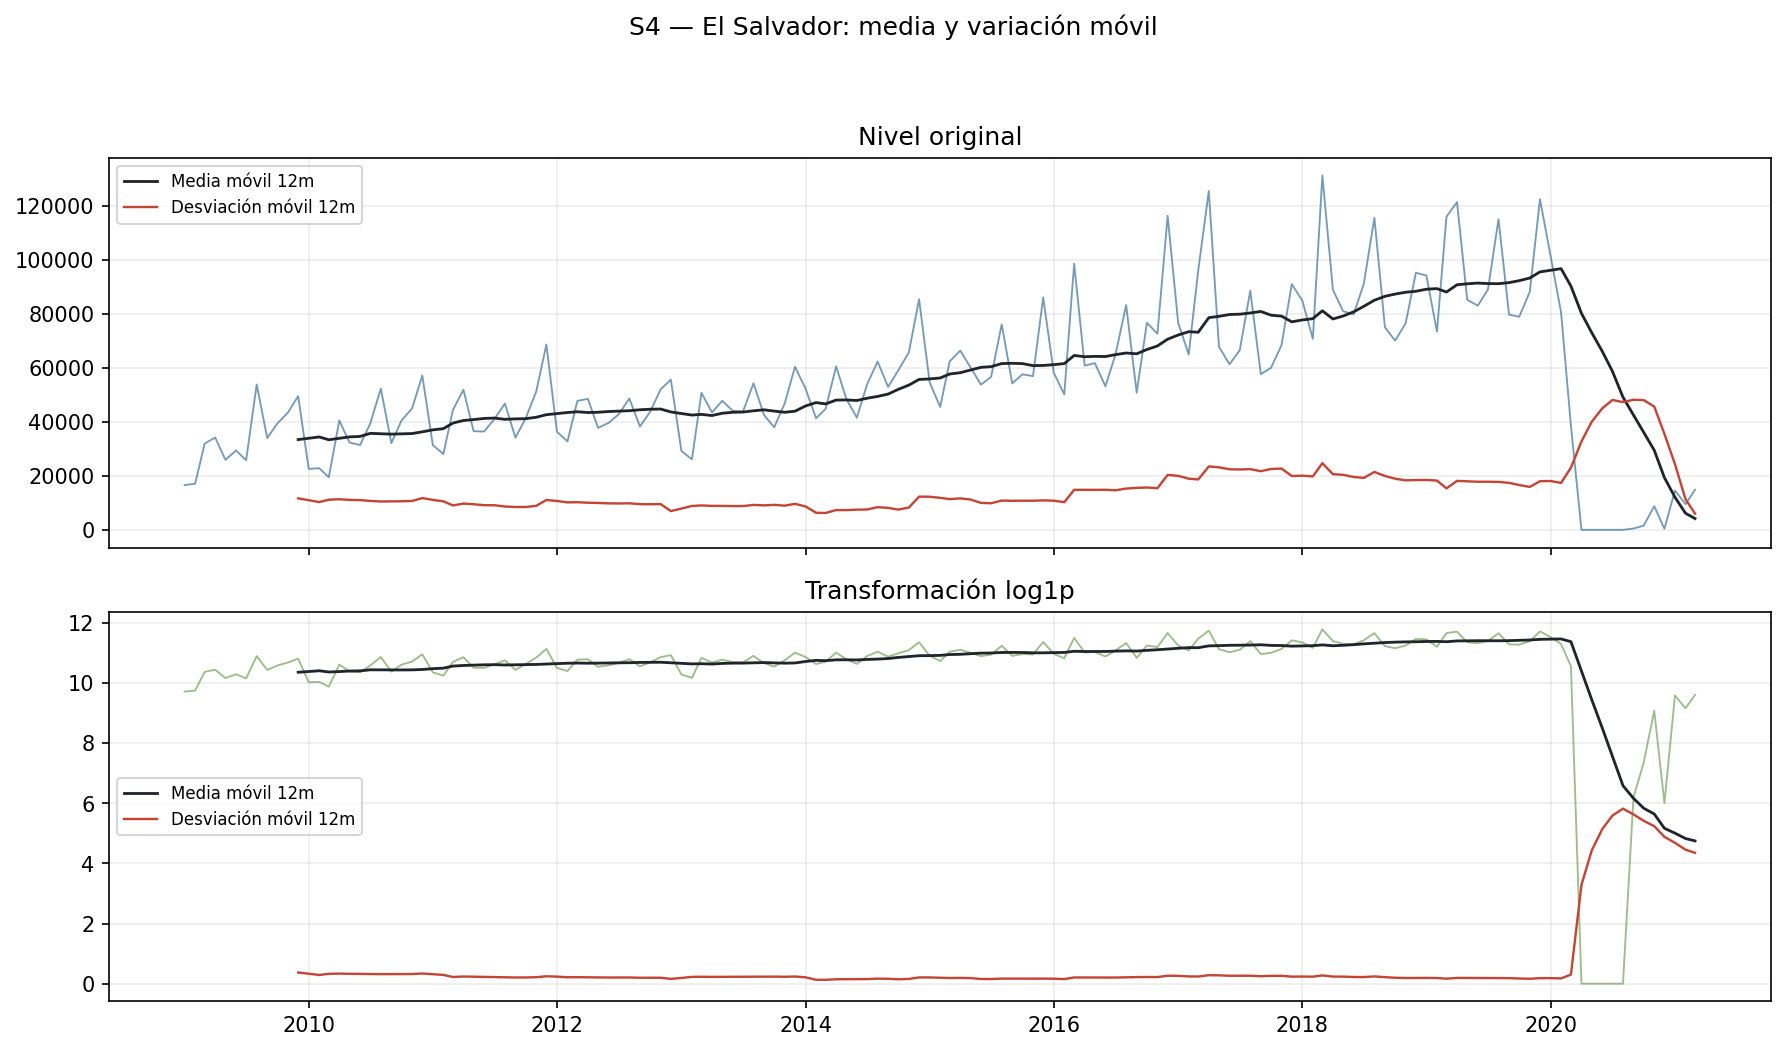

In [2]:
display(Image(filename=str(DIR_IMG / "s4_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s4_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s4_varianza.png")))

El nivel original no es estacionario, pero `log1p` obtiene ADF `p<0.001` y
KPSS `p=0.10`; por ello `d=0` es suficiente en la serie transformada. La ACF
decae y la PACF se concentra en lag 1, lo que motiva ARIMA(1,0,0). También se
evalúan candidatos con `d=1`, un SARIMA anual y la propuesta automática
ARIMA(2,0,2).

,transformacion,p_ADF,p_KPSS,veredicto
0,Nivel,0.3333,0.0382,NO estacionaria (ambas pruebas coinciden)
1,log1p,0.0005,0.1000,estacionaria (ambas pruebas coinciden)
2,log1p + d=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)
3,log1p + D=1,0.9625,0.0384,NO estacionaria (ambas pruebas coinciden)
4,log1p + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


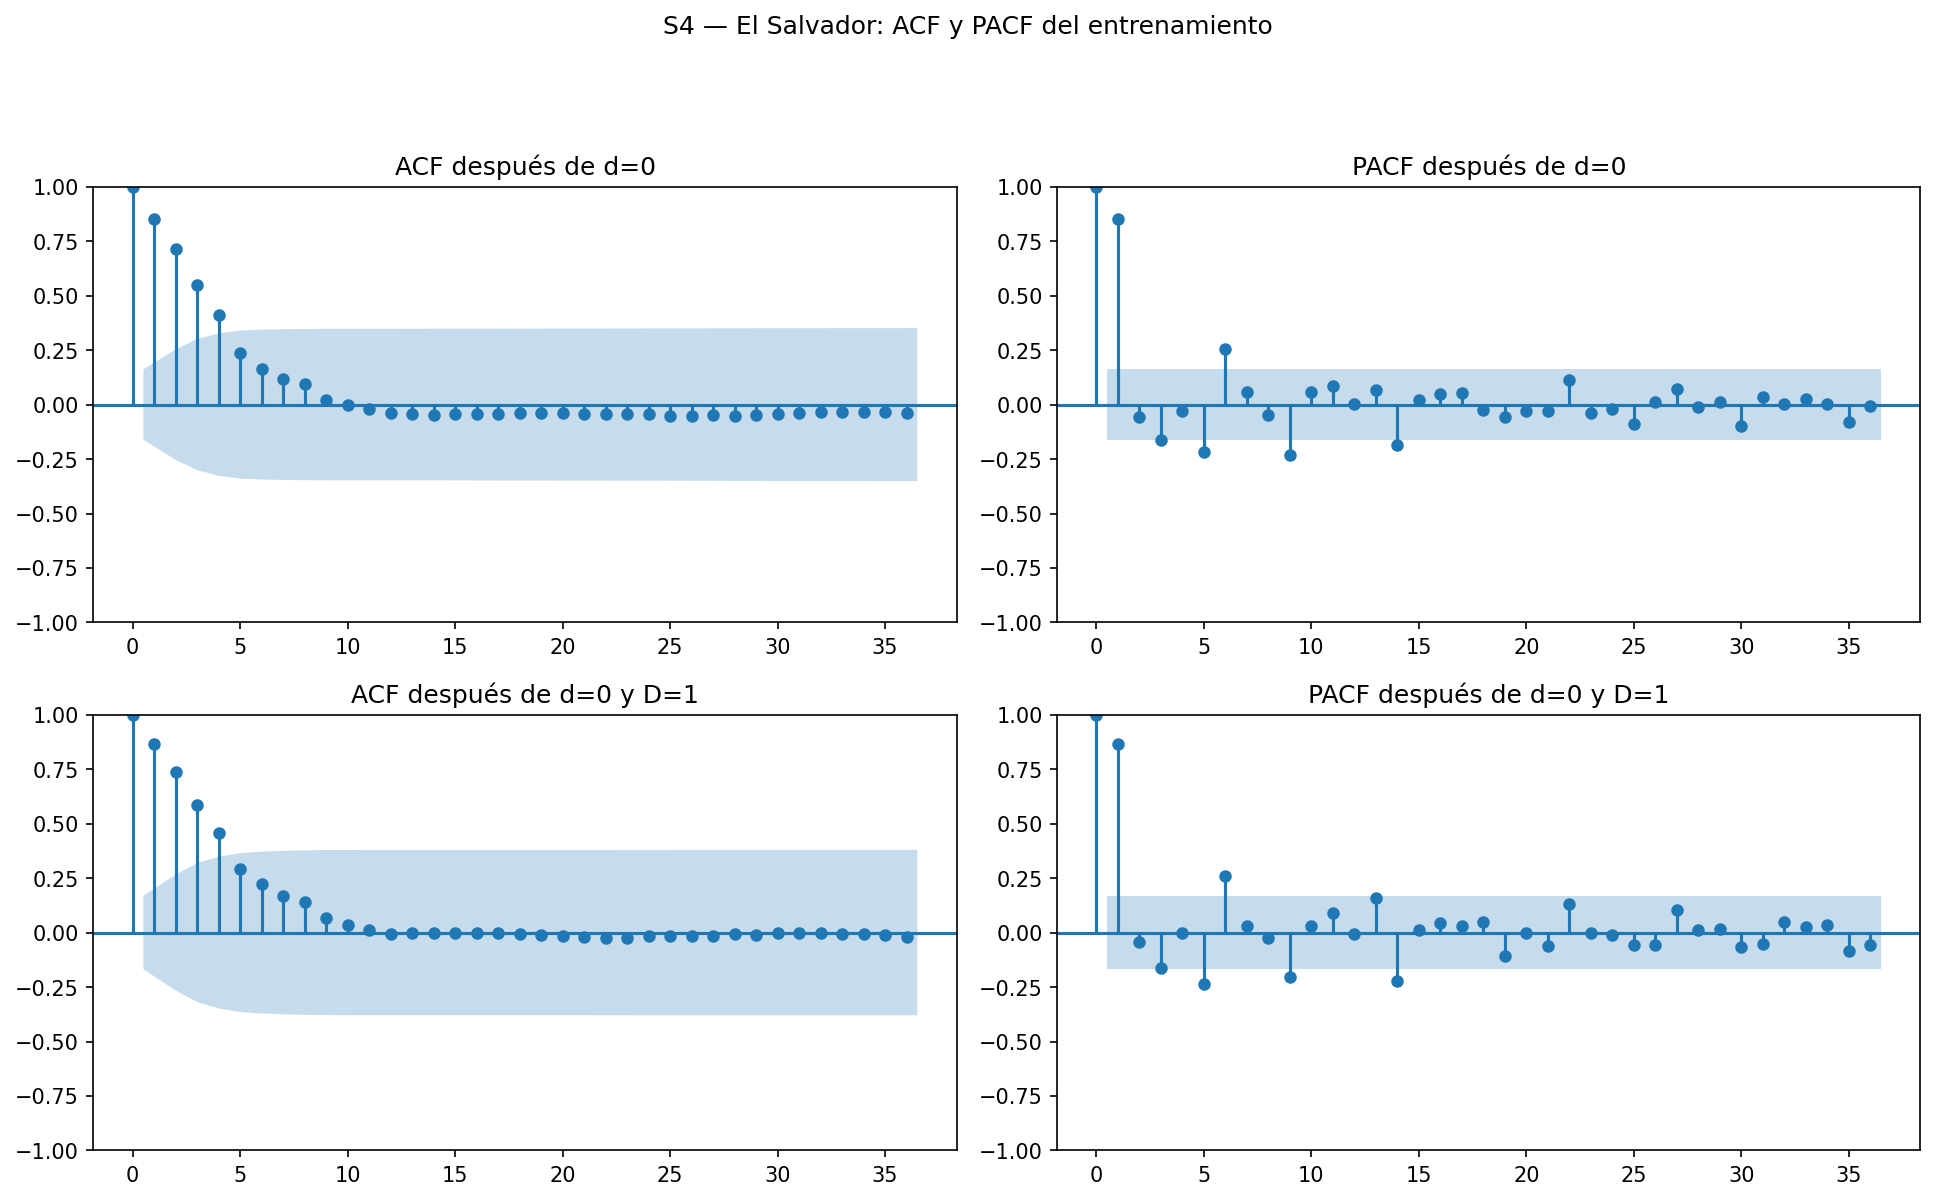

In [3]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S4_el_salvador",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s4_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,Prophet,NaN,NaN,5.308098e+04,5.945504e+04,8.791780e+01,0.0000,0.0,True
1,"ARIMA(0,1,1)",451.5322,457.4718,8.133496e+04,9.286043e+04,7.519410e+01,0.0002,0.0,False
2,"ARIMA(1,1,0)",453.9266,459.8801,8.134956e+04,9.287620e+04,7.520080e+01,0.0003,0.0,False
3,Holt-Winters,NaN,NaN,8.370094e+04,9.373749e+04,8.258930e+01,0.8862,0.0,False
4,Suavizamiento exponencial simple,NaN,NaN,8.397695e+04,9.546670e+04,7.803590e+01,0.0000,0.0,False
5,"ARIMA(1,1,1)",445.4849,454.3943,8.543098e+04,9.671217e+04,8.274560e+01,0.0004,0.0,False
6,Seasonal Naive,NaN,NaN,9.166209e+04,1.021985e+05,9.405320e+01,0.0000,0.0,False
7,"ARIMA(1,0,0)",455.6720,461.6393,9.155983e+04,1.035125e+05,8.636470e+01,0.0002,0.0,False
8,"auto_arima(2, 0, 2)x(0, 0, 0, 12)",444.6046,459.4537,9.378213e+04,1.048021e+05,9.337800e+01,0.0026,0.0,False
9,"SARIMA(1,1,1)(0,1,1,12)",393.9898,405.1397,1.307116e+09,8.817306e+09,1.180794e+06,0.0015,0.0,False


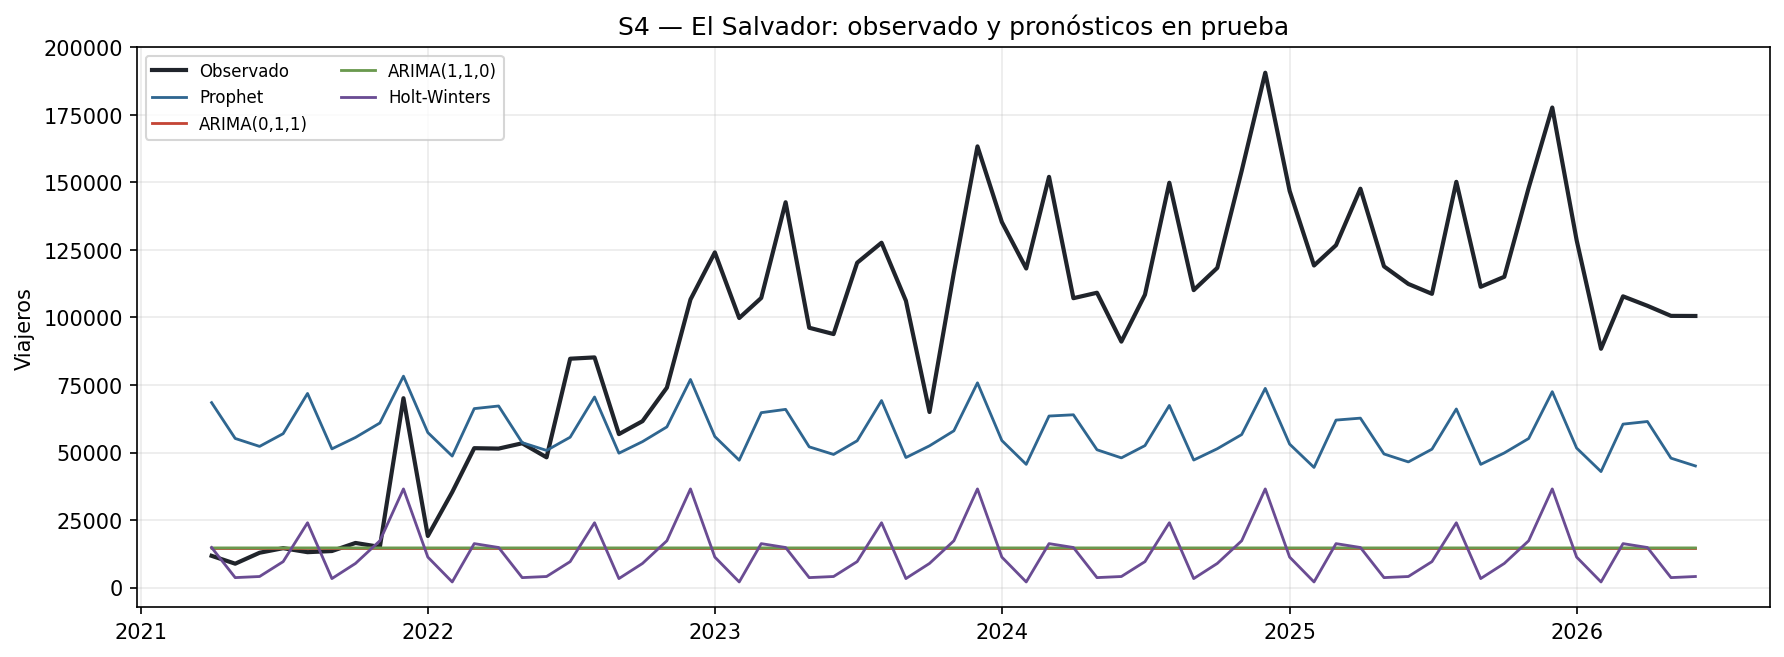

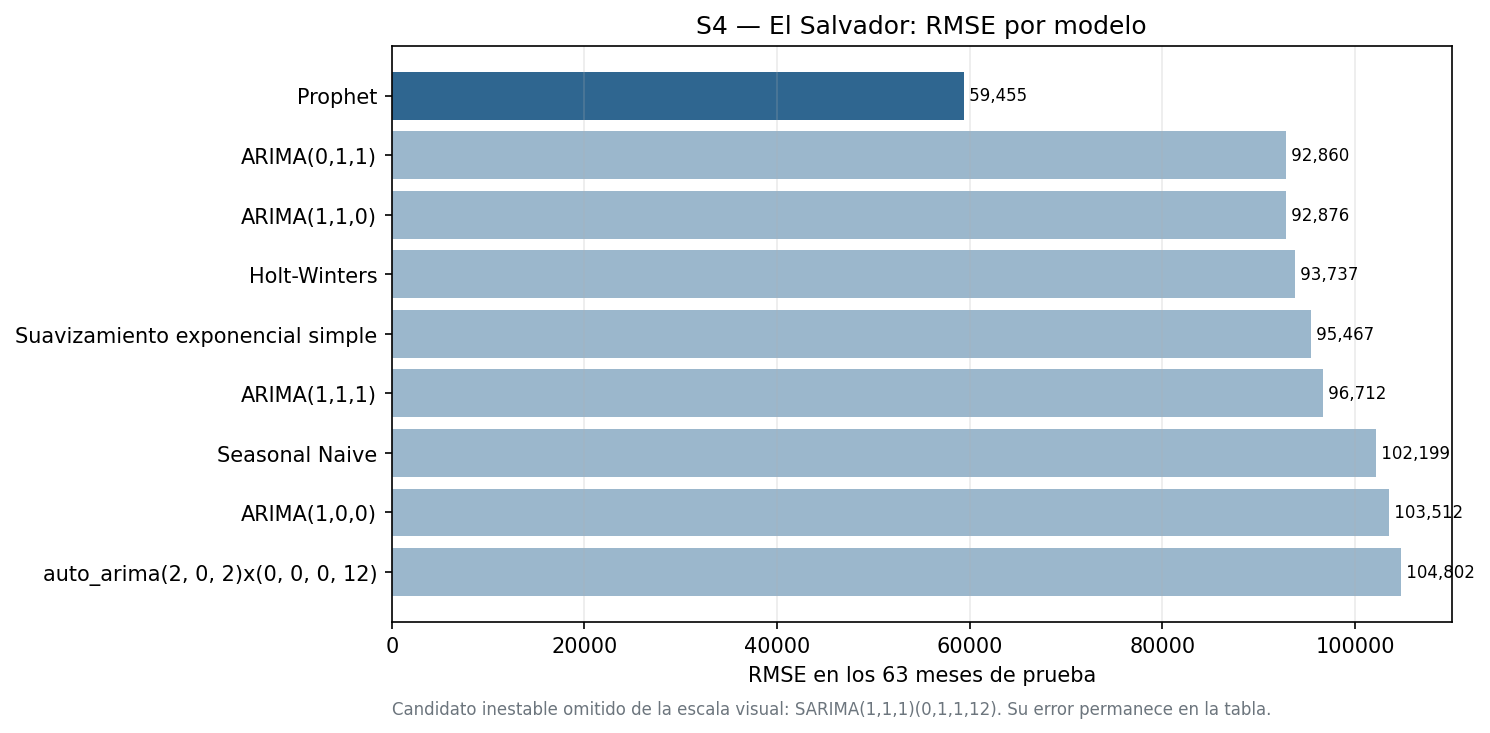

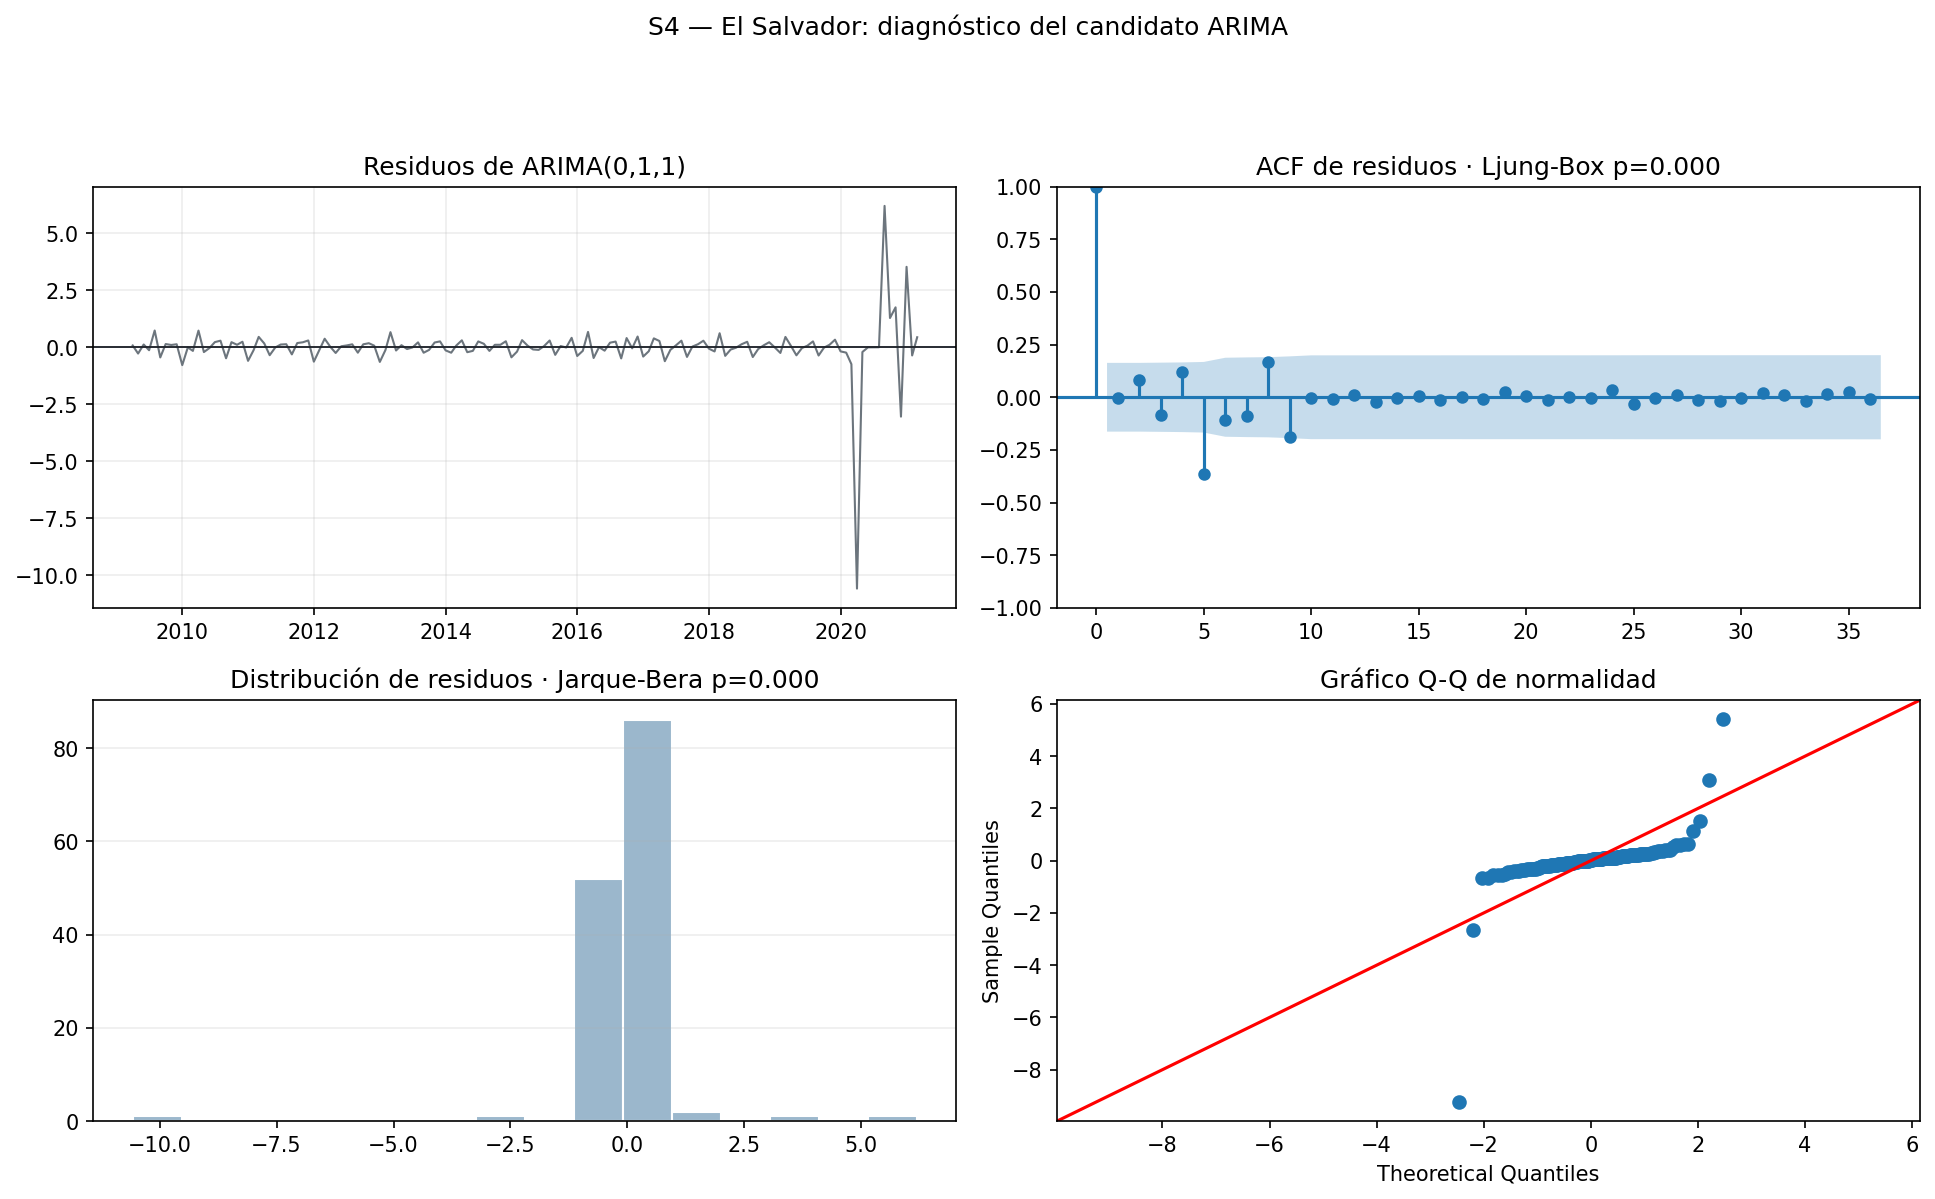

In [4]:
display(
    metricas.loc[
        metricas["serie"] == "S4_el_salvador",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s4_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s4_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s4_residuos.png")))

Prophet obtiene el menor RMSE de S4 (59,455). Ningún modelo reproduce por
completo la recuperación posterior al piso incluido al final del
entrenamiento. El SARIMA estacional genera pronósticos explosivos pese a su
AIC bajo, evidencia de que AIC/BIC no bastan para elegir un pronóstico.

## S5 — Estados Unidos

S5 presenta la mayor fuerza estacional de Países (0.704) y fuerza de tendencia
0.709. Sus cinco ceros pandémicos también obligan a preferir descomposición
aditiva y `log1p`; la correlación media-desviación baja de 0.898 a -0.163.

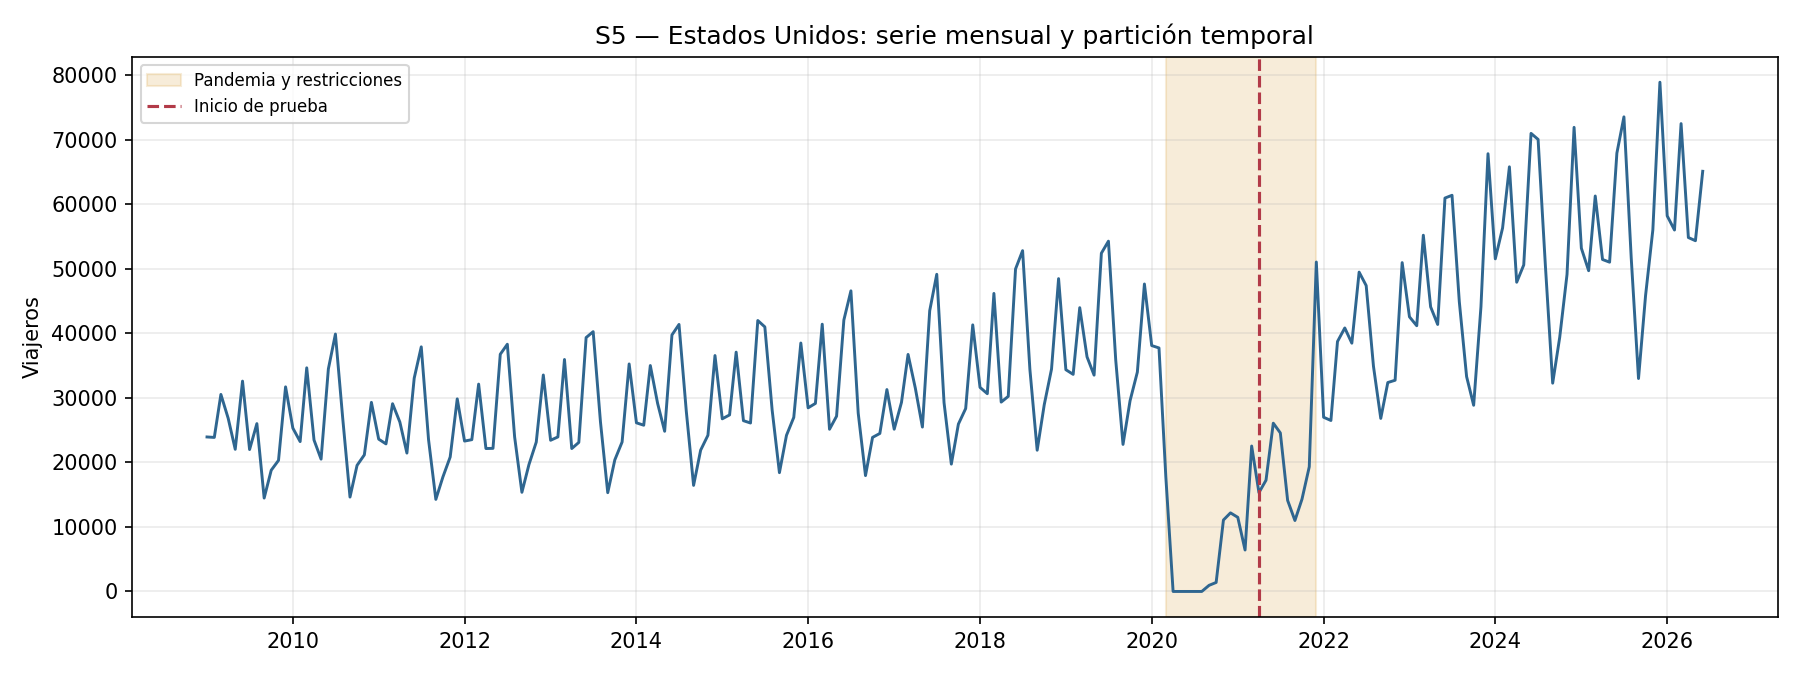

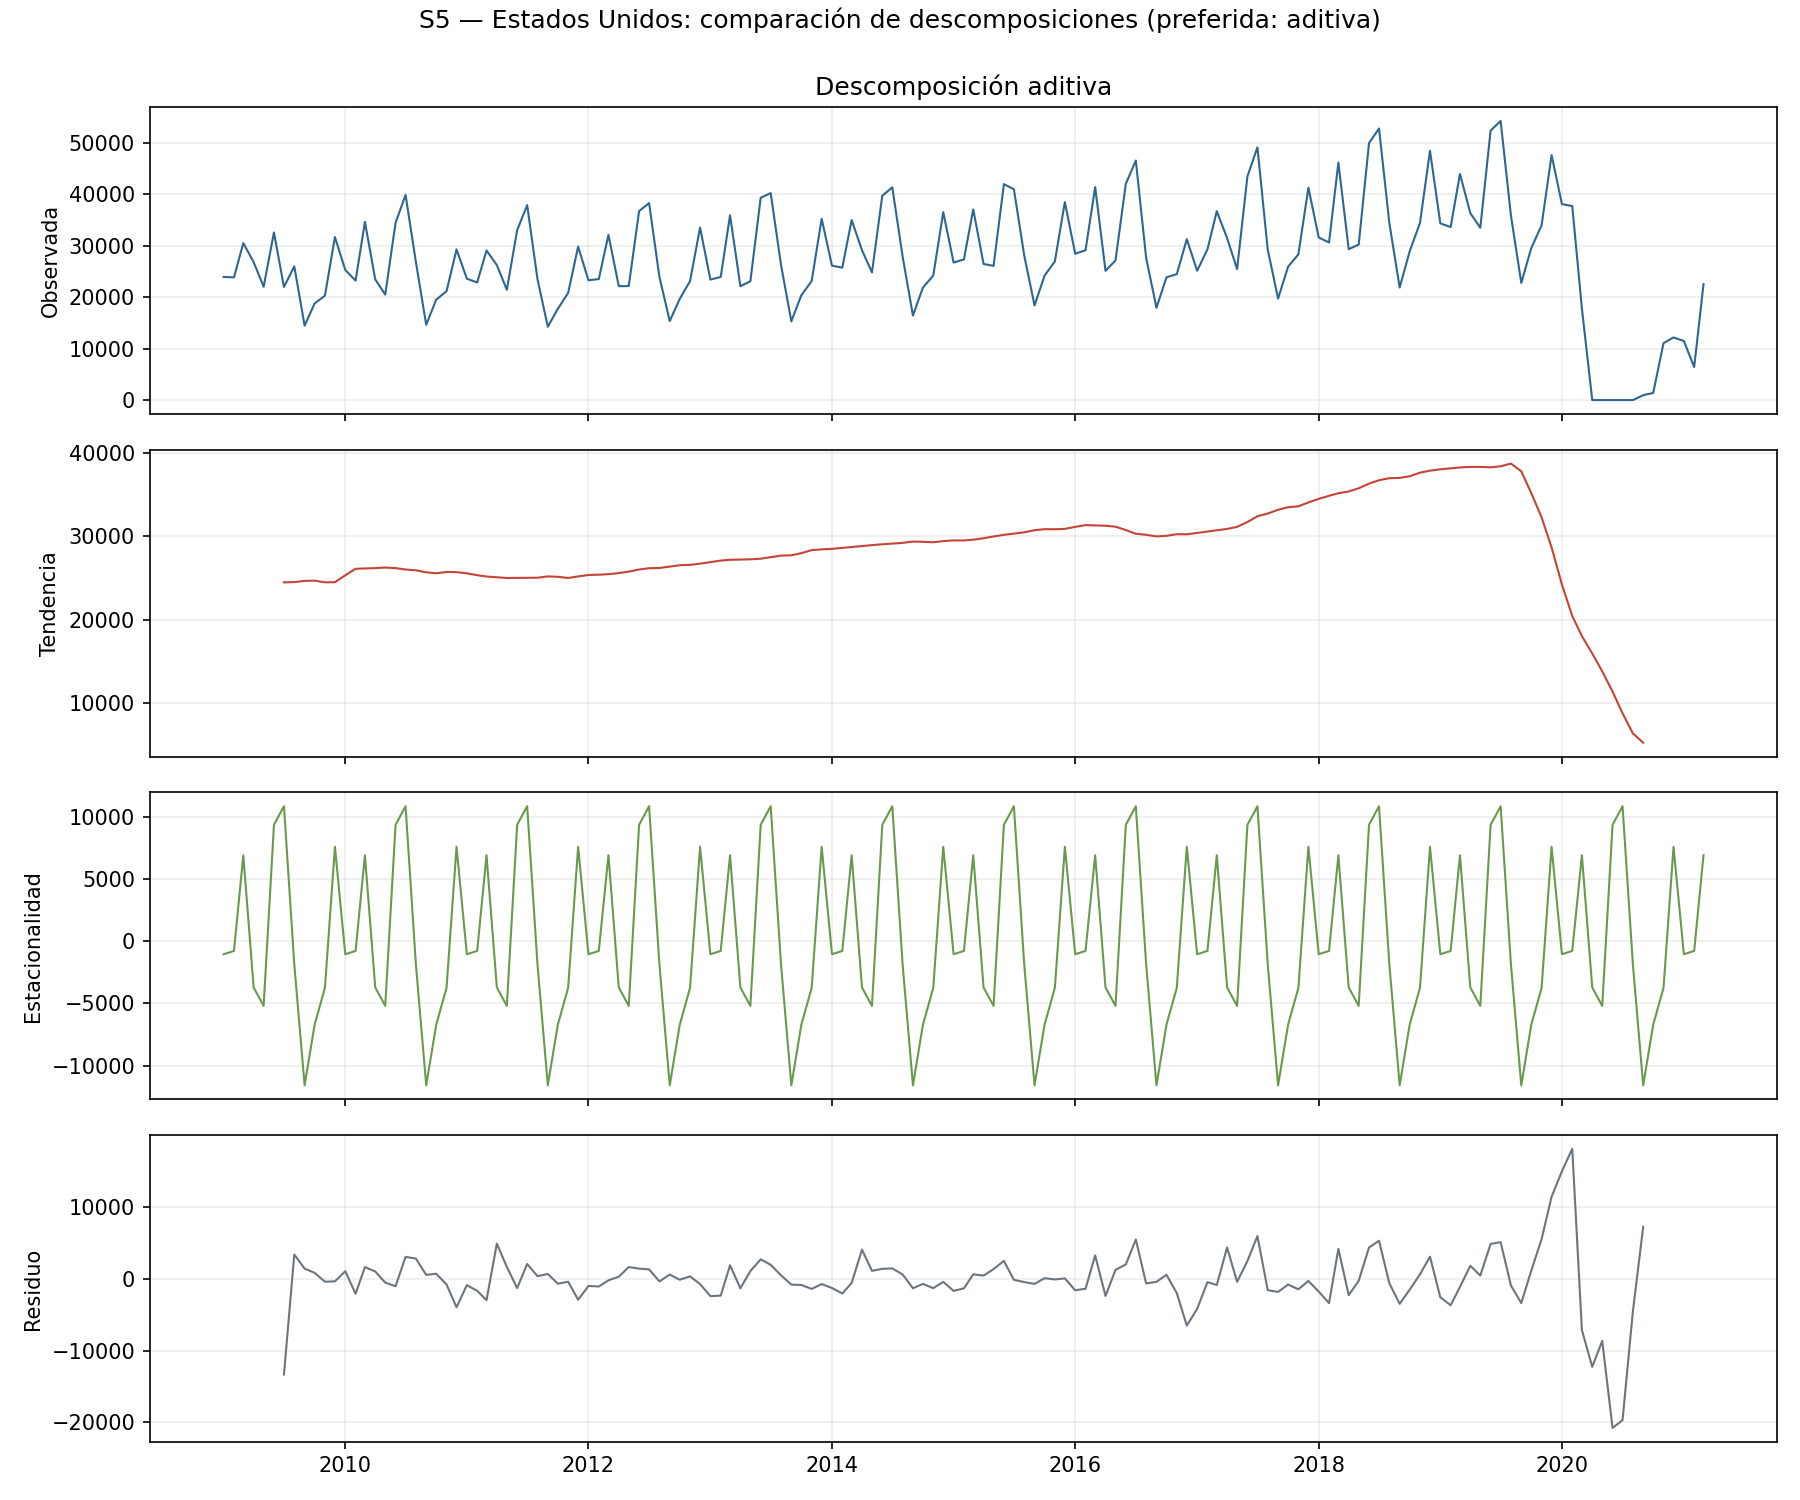

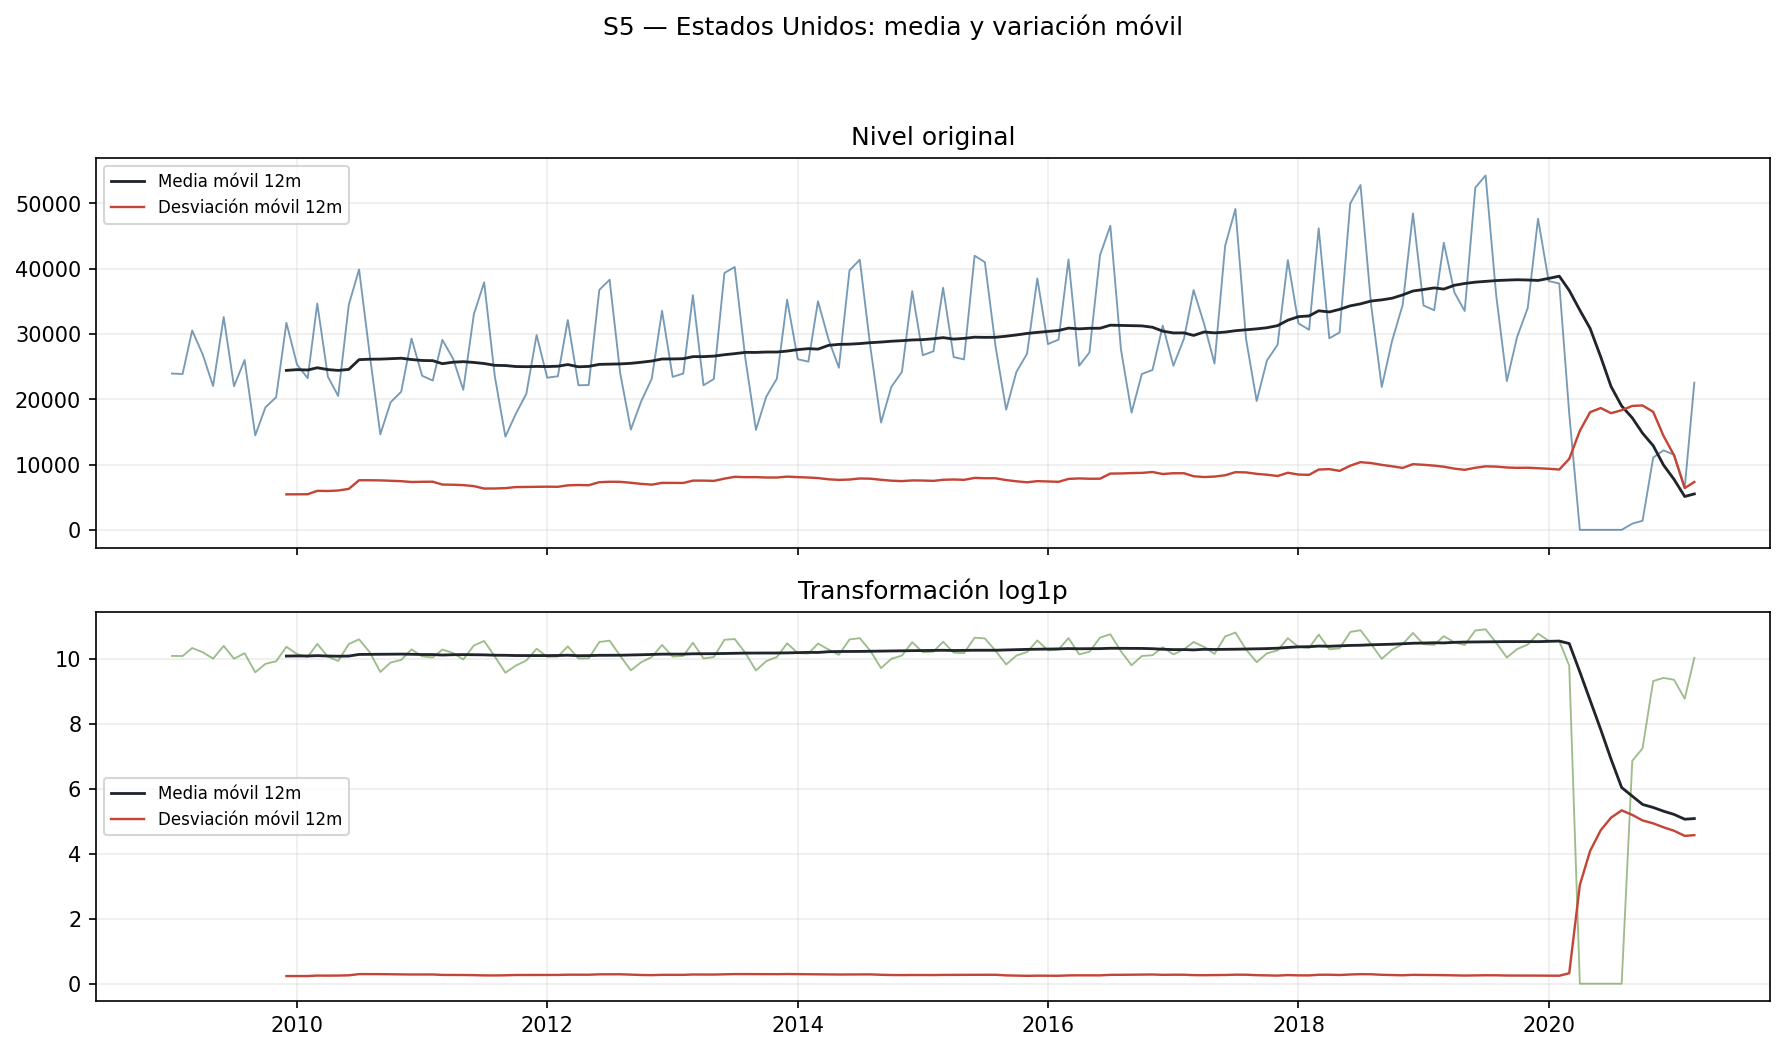

In [5]:
display(Image(filename=str(DIR_IMG / "s5_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s5_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s5_varianza.png")))

En `log1p` las pruebas son mixtas, pero después de `d=1` ADF y KPSS coinciden
en estacionariedad. Como ACF/PACF no muestran un corte corto inequívoco, se
comparan AR(1), MA(1), ARMA(1,1) y un SARIMA anual.

,transformacion,p_ADF,p_KPSS,veredicto
5,Nivel,0.0208,0.1000,estacionaria (ambas pruebas coinciden)
6,log1p,0.0821,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
7,log1p + d=1,0.0487,0.1000,estacionaria (ambas pruebas coinciden)
8,log1p + D=1,0.9286,0.0616,"resultado mixto: KPSS dice estacionaria, ADF no"
9,log1p + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


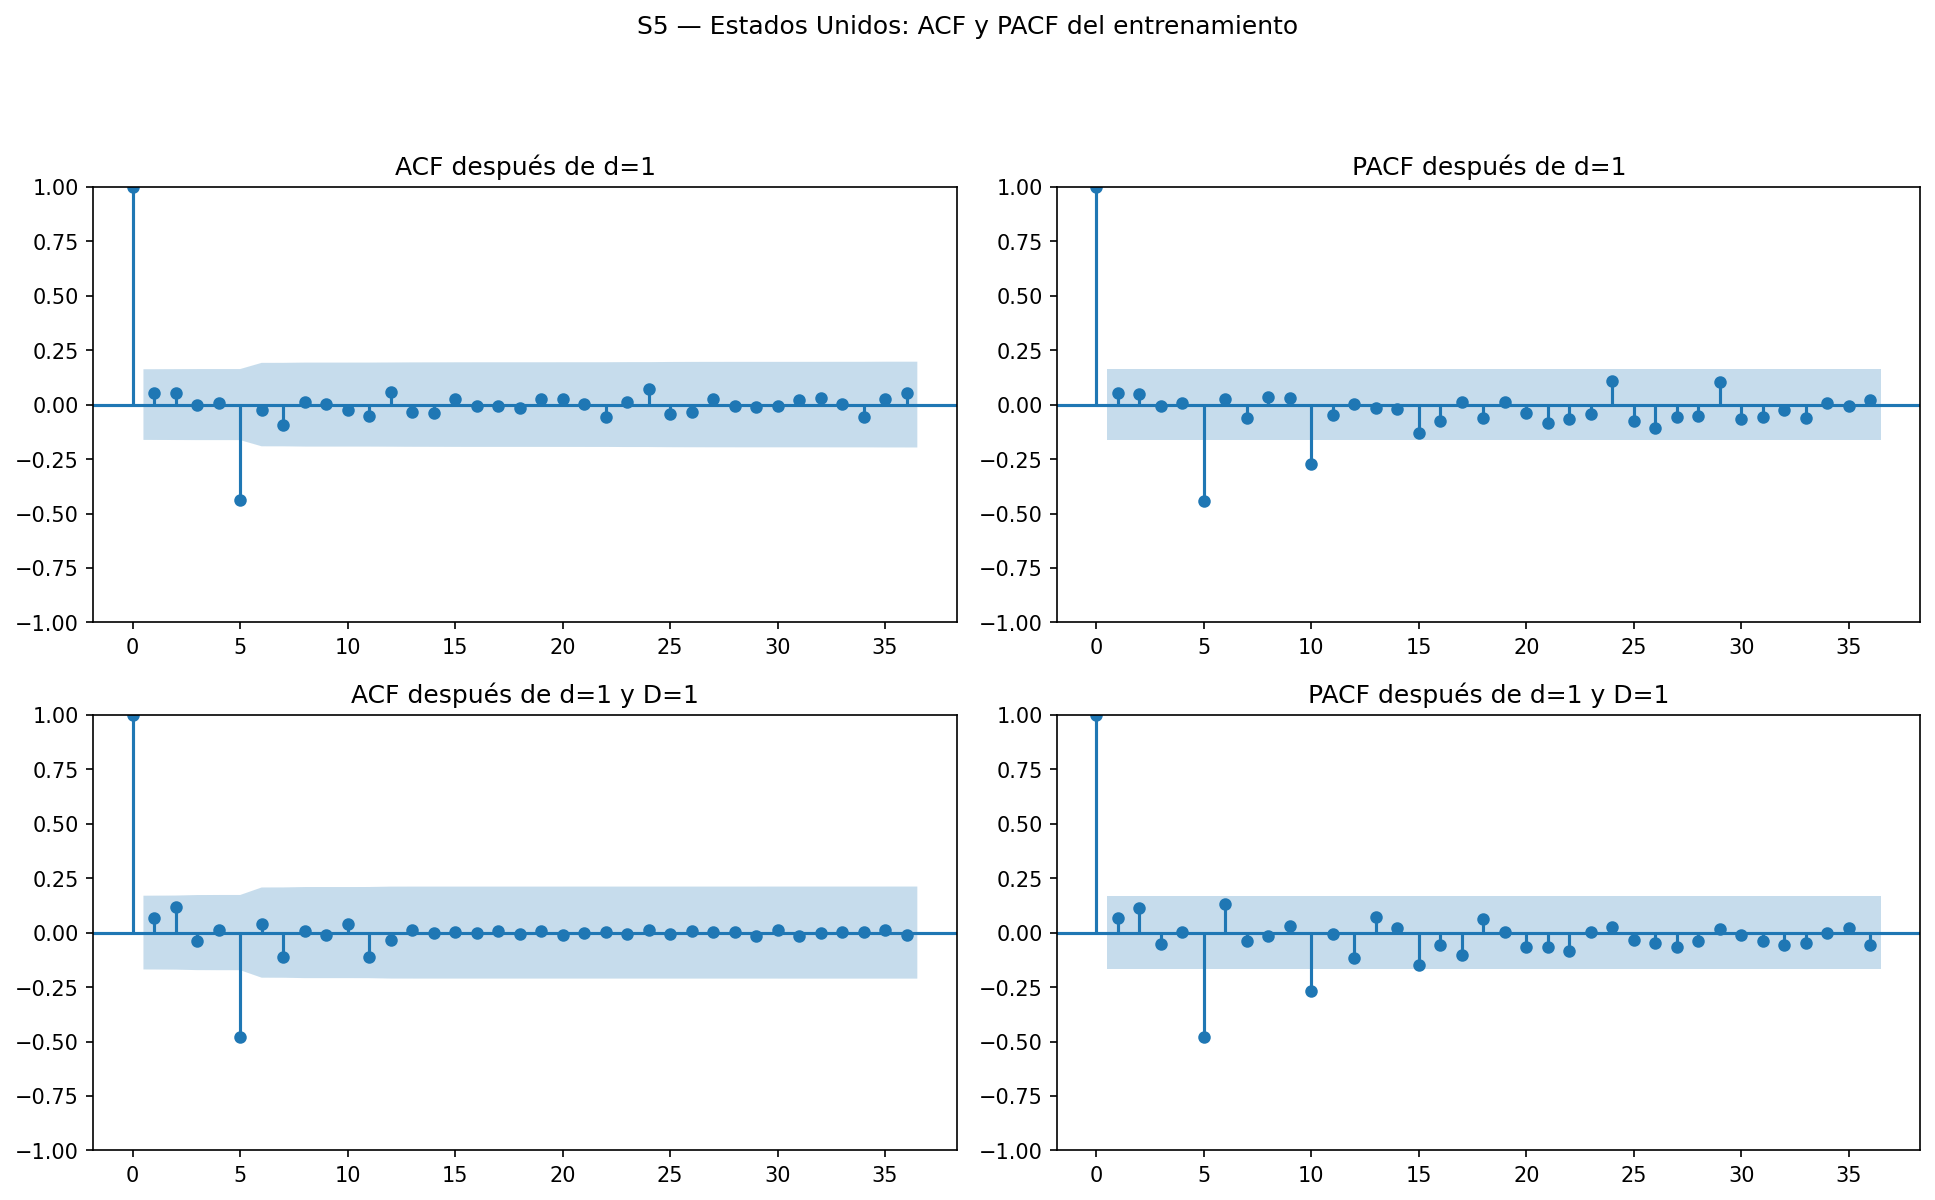

In [6]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S5_estados_unidos",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s5_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
10,"ARIMA(1,1,1)",431.9074,440.8168,22974.8341,26793.5240,47.0824,0.0015,0.0000,True
11,"ARIMA(1,1,0)",432.0448,437.9983,23442.4239,27251.7084,47.9101,0.0013,0.0000,False
12,"ARIMA(0,1,1)",430.0751,436.0147,23617.5751,27423.3968,48.2126,0.0013,0.0000,False
13,Prophet,NaN,NaN,30361.5064,34043.5118,61.3144,0.0000,0.0000,False
14,Holt-Winters,NaN,NaN,31256.7401,34100.7081,65.2448,0.4530,0.0000,False
15,Suavizamiento exponencial simple,NaN,NaN,32301.5361,36173.8841,64.2841,0.0000,0.5807,False
16,"auto_arima(0, 1, 0)x(0, 1, 0, 12)",401.6585,404.5488,34754.9788,38984.7398,77.7776,0.0001,0.0000,False
17,"SARIMA(1,1,1)(0,1,1,12)",376.8823,388.0323,36709.2649,40429.4523,78.8609,0.0002,0.0000,False
18,Seasonal Naive,NaN,NaN,40733.3470,43733.3599,88.6862,0.0000,0.0000,False


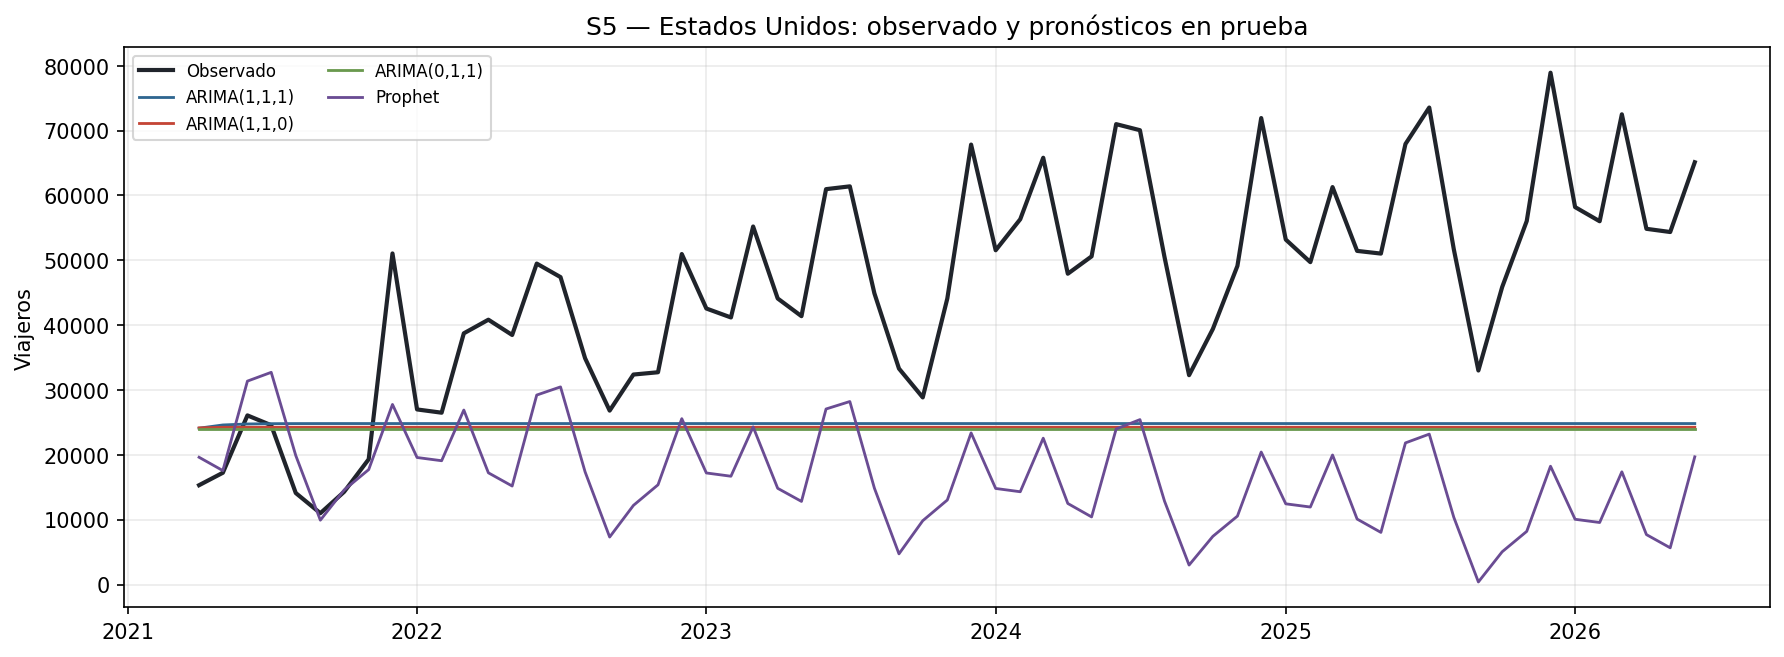

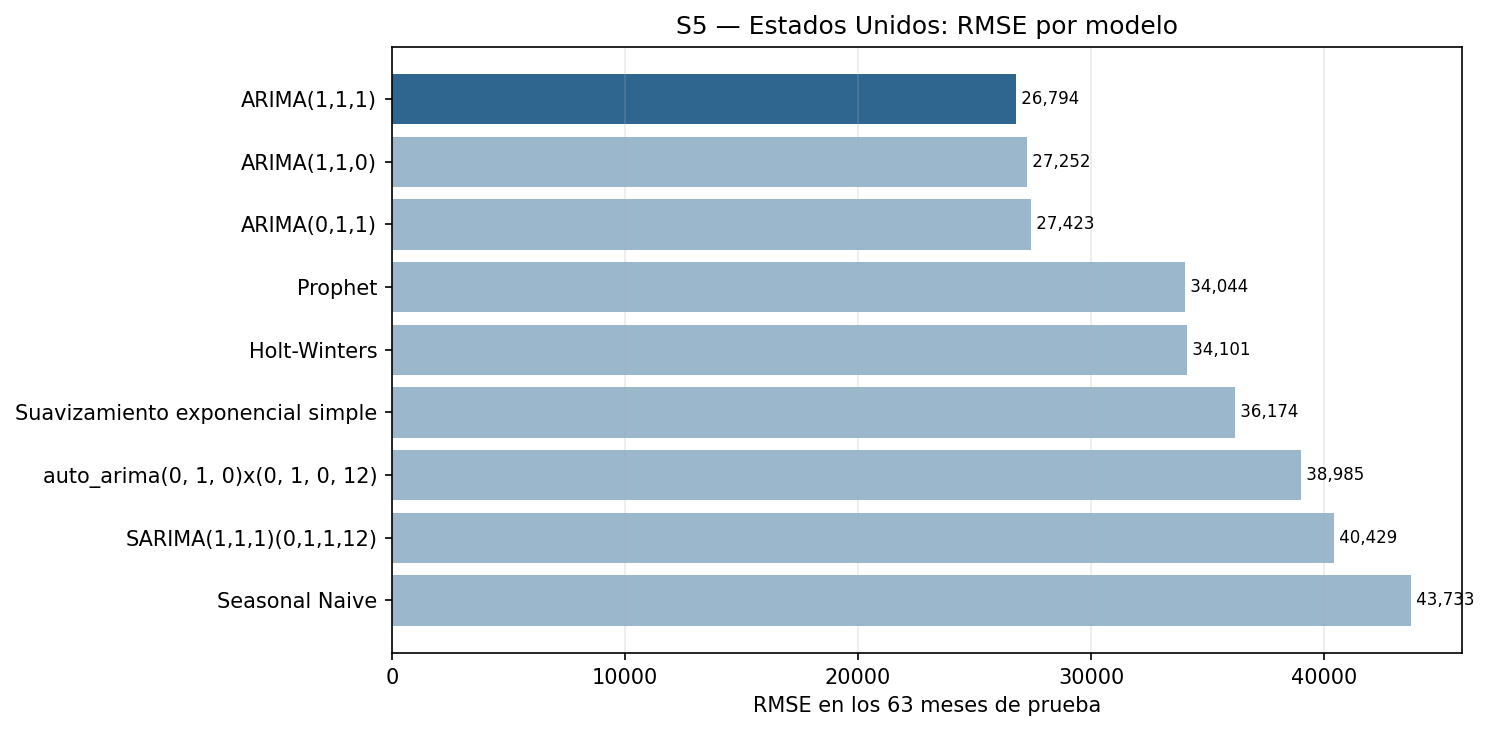

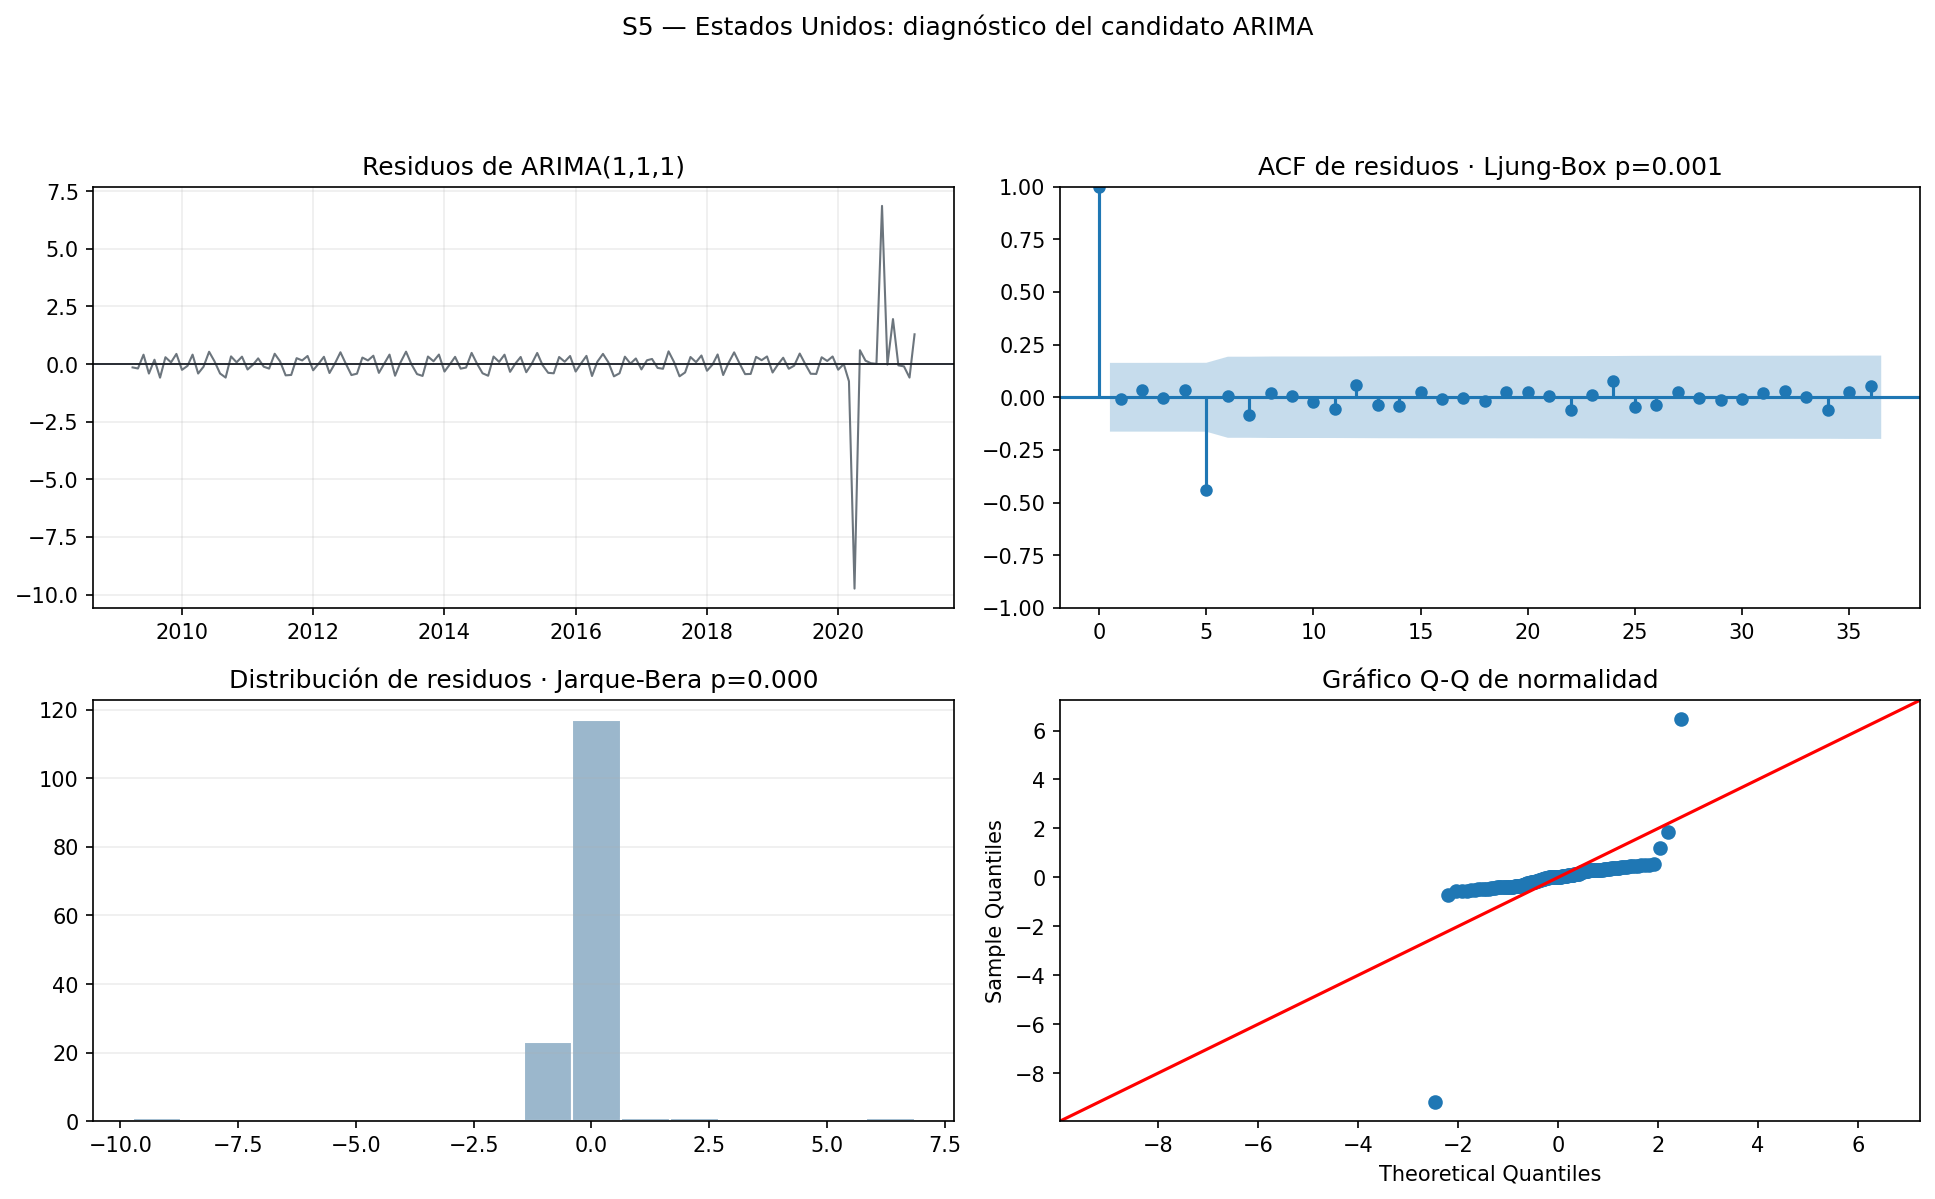

In [7]:
display(
    metricas.loc[
        metricas["serie"] == "S5_estados_unidos",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s5_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s5_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s5_residuos.png")))

ARIMA(1,1,1) obtiene el menor RMSE de S5 (26,794). Sus residuos todavía
conservan autocorrelación (`p_Ljung-Box=0.0015`) y no son normales, por lo que
se selecciona como el mejor de los candidatos evaluados, no como un modelo
perfectamente especificado.

## S6 — Guatemala

S6 representa principalmente el retorno de residentes guatemaltecos. Tiene
fuerza de tendencia 0.840 y fuerza estacional 0.506 en entrenamiento. La
descomposición multiplicativa es descriptivamente preferida y `log1p` reduce
la correlación media-desviación de 0.830 a -0.592.

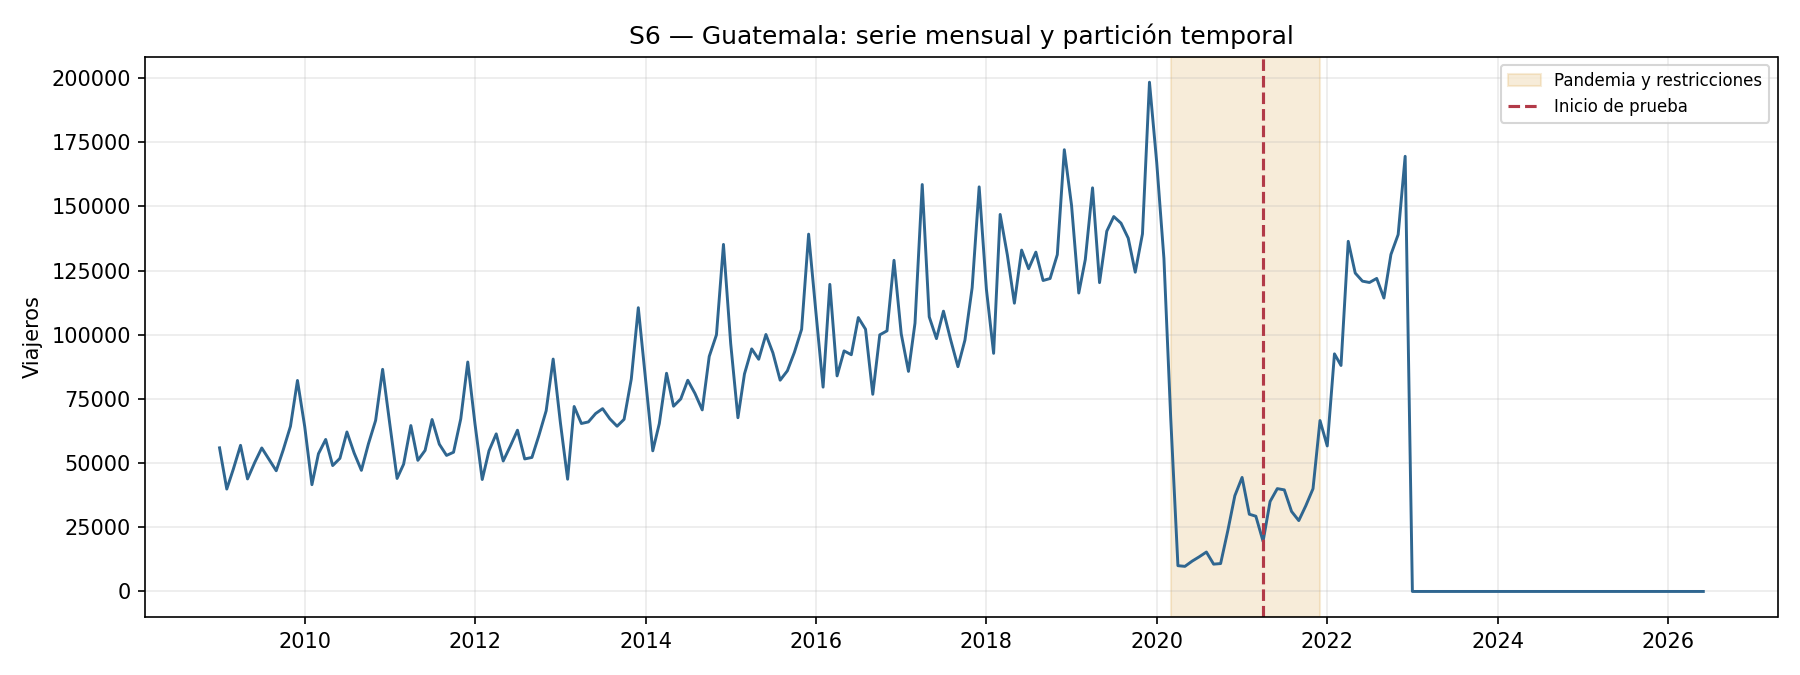

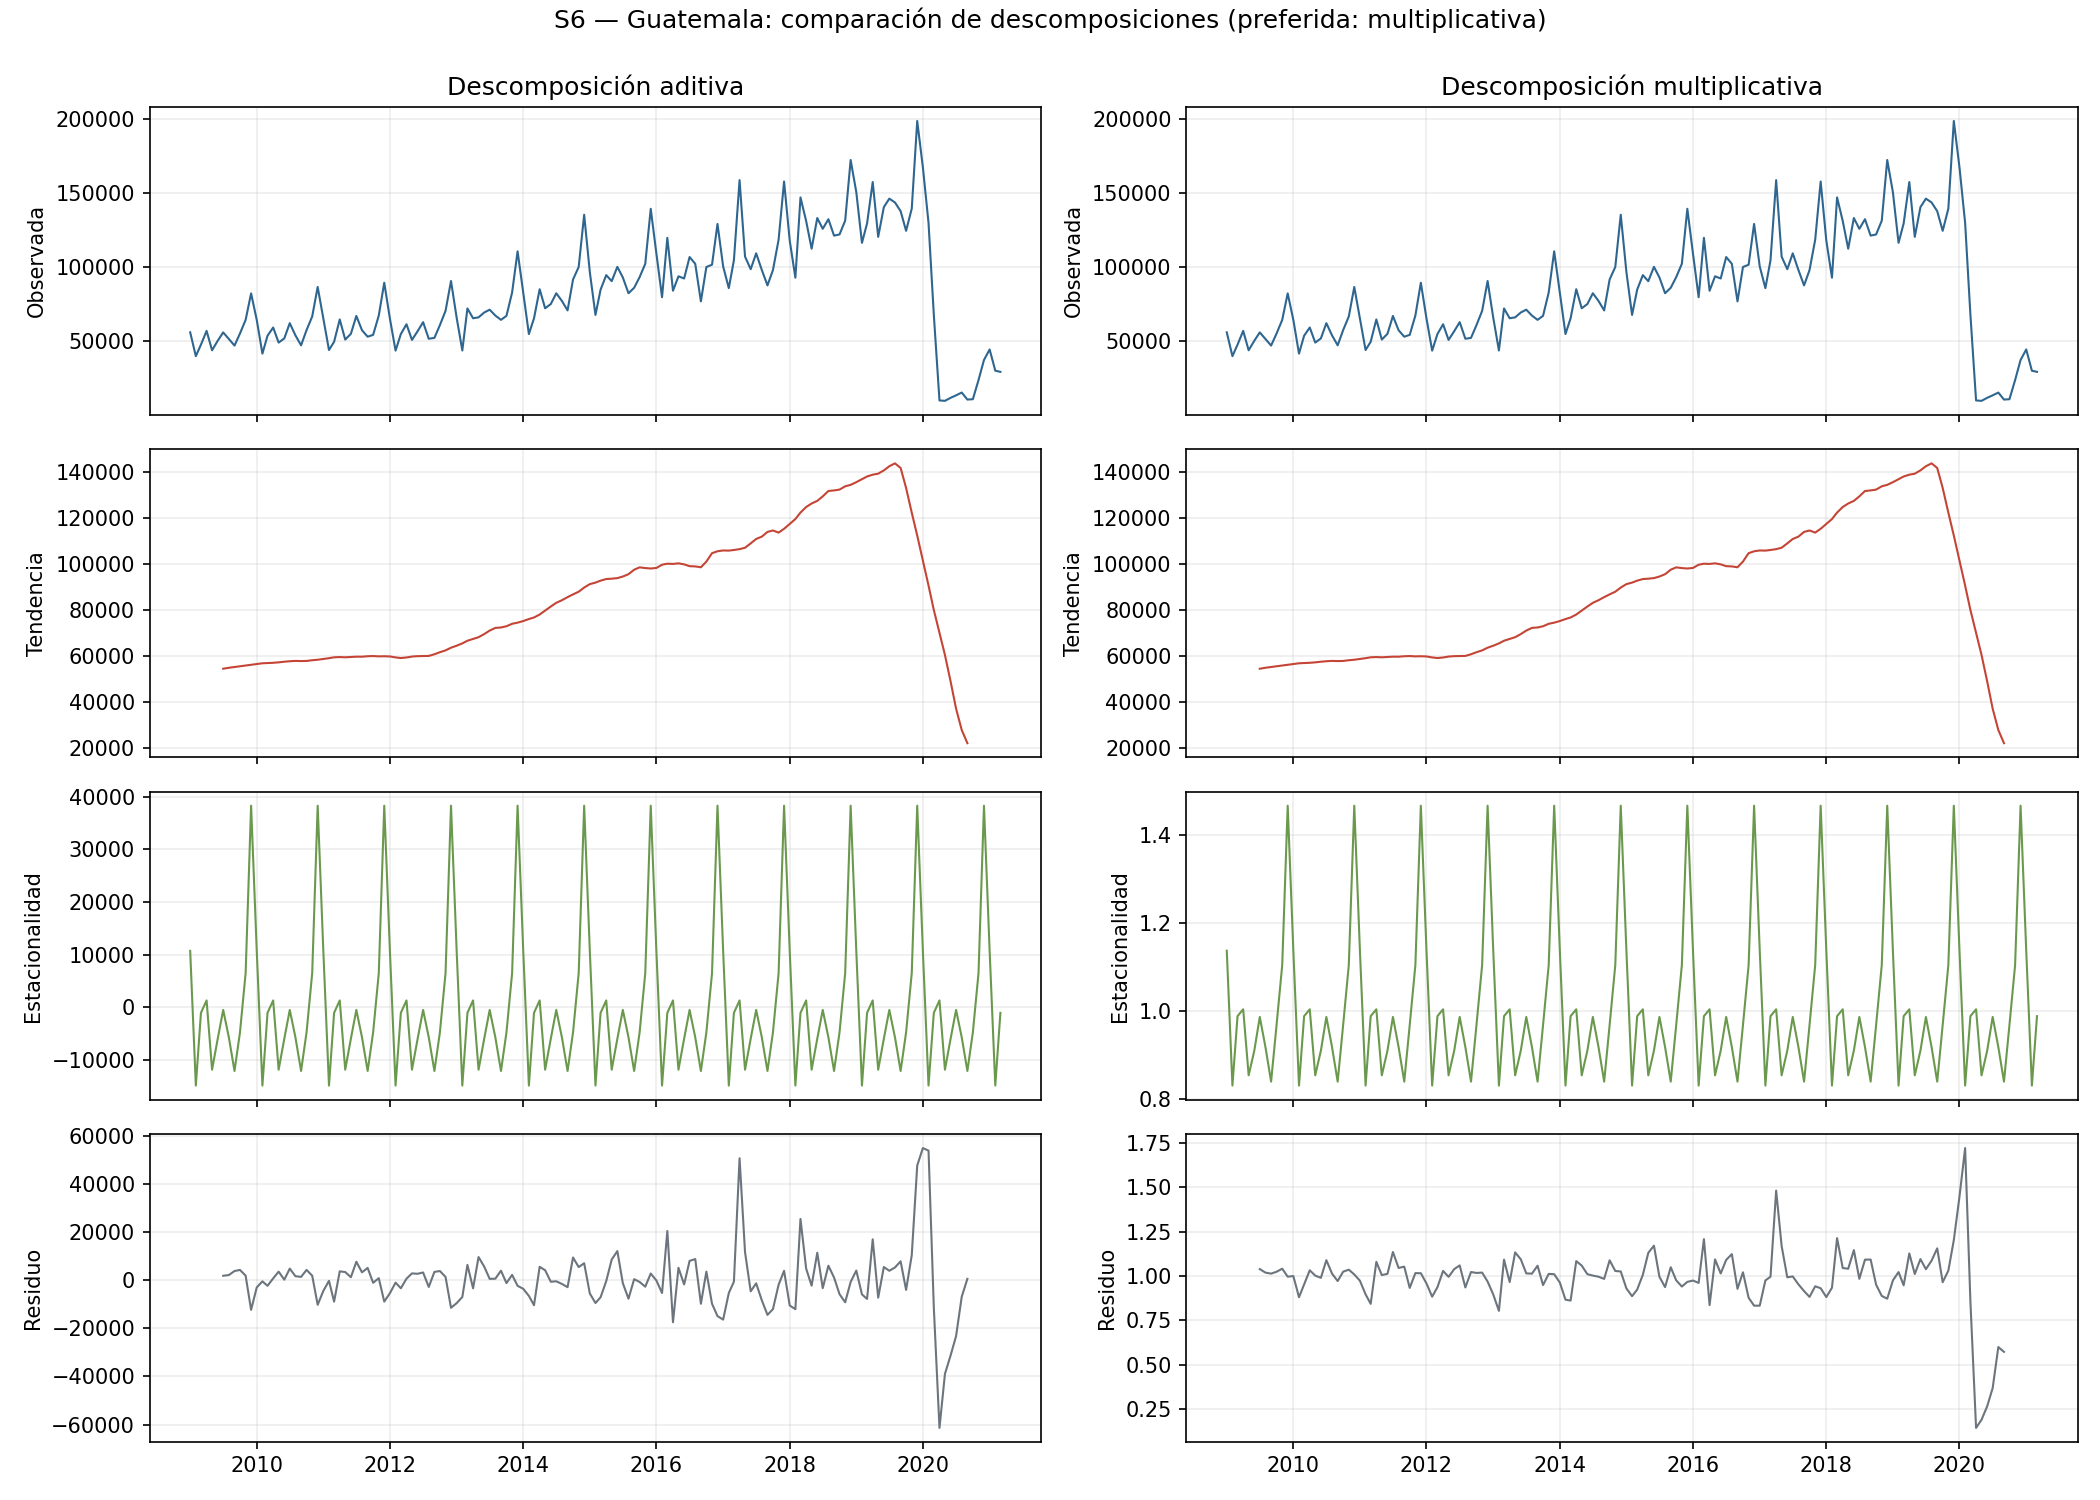

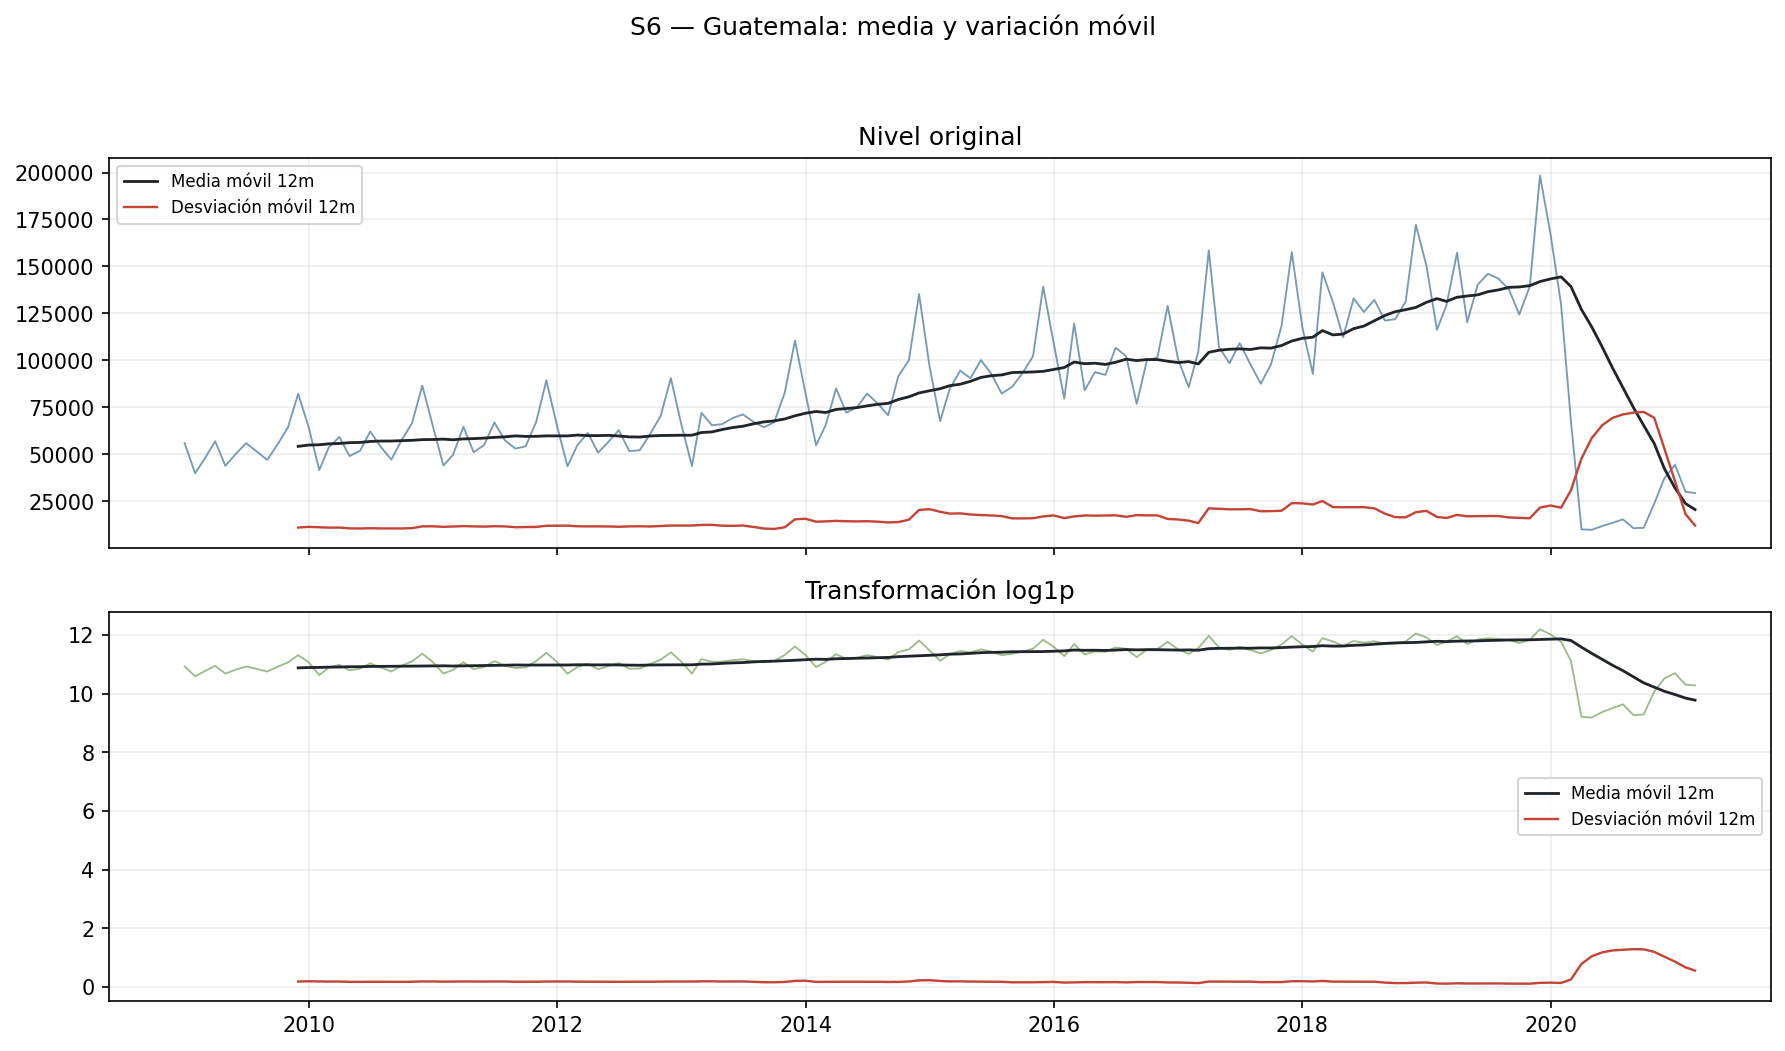

In [8]:
display(Image(filename=str(DIR_IMG / "s6_serie_particion.png")))
display(Image(filename=str(DIR_IMG / "s6_descomposicion.png")))
display(Image(filename=str(DIR_IMG / "s6_varianza.png")))

S6 requiere `d=1`: ADF y KPSS coinciden después de la primera diferencia. La
PACF conserva señal en lag 2 y la ACF en lag 12, por lo que se agrega un
candidato con `p=2` y candidatos SARIMA al contraste de órdenes cortos.

,transformacion,p_ADF,p_KPSS,veredicto
10,Nivel,0.2136,0.0213,NO estacionaria (ambas pruebas coinciden)
11,log1p,0.3834,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
12,log1p + d=1,0.0345,0.1000,estacionaria (ambas pruebas coinciden)
13,log1p + D=1,0.8729,0.0281,NO estacionaria (ambas pruebas coinciden)
14,log1p + d=1 + D=1,0.0031,0.1000,estacionaria (ambas pruebas coinciden)


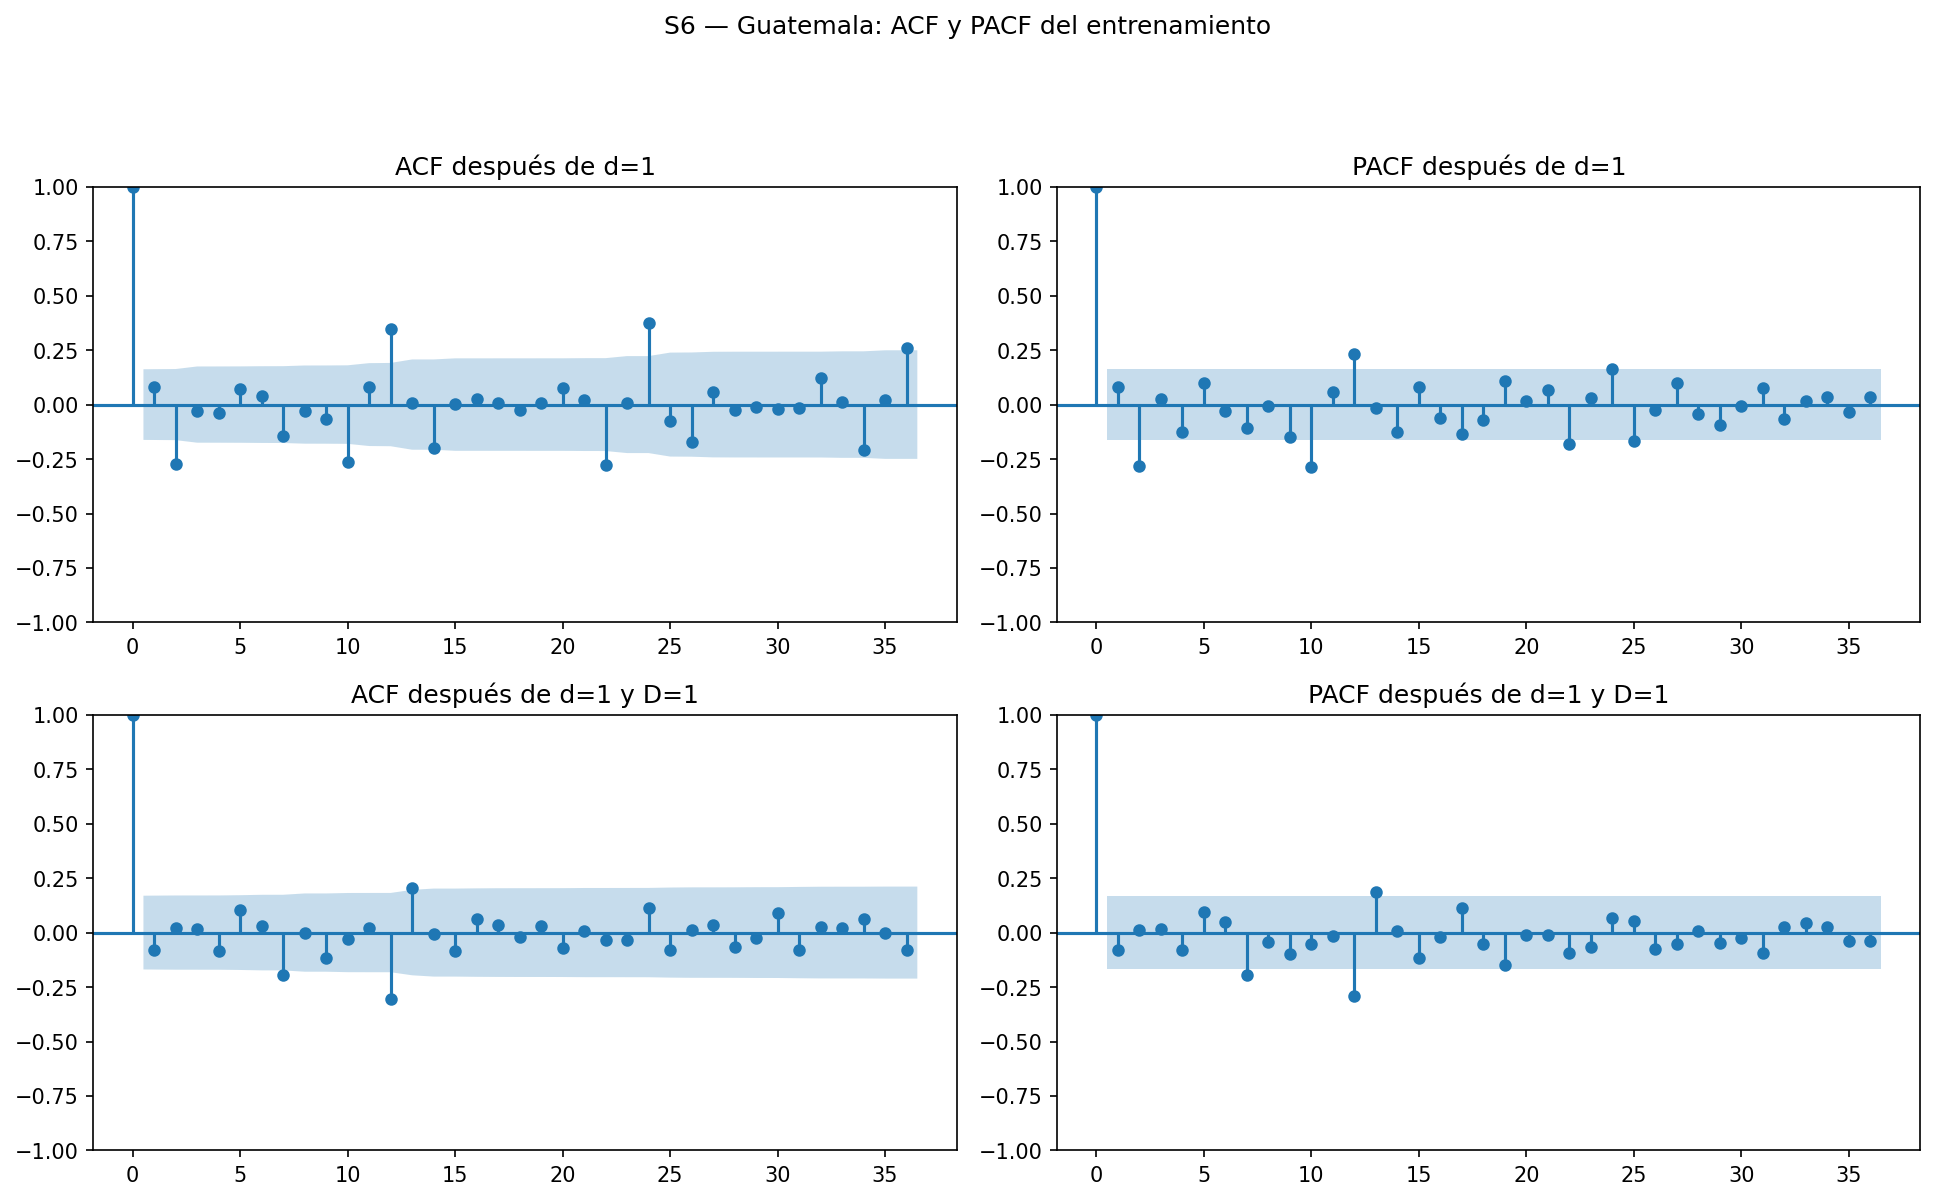

In [9]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S6_guatemala",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s6_acf_pacf.png")))

,modelo,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
19,"SARIMA(1,1,1)(0,1,1,12)",13.4183,24.5683,27316.8366,47260.2458,66.2170,0.0653,0.0000,True
20,"ARIMA(1,1,0)",43.4089,49.3624,37863.4746,47345.6103,52.7156,0.0000,0.0000,False
21,"ARIMA(0,1,1)",42.2795,48.2191,38003.3674,47358.0846,52.3739,0.0000,0.0000,False
22,Suavizamiento exponencial simple,NaN,NaN,38141.1501,47372.9420,52.0387,0.0000,0.0002,False
23,"ARIMA(1,1,1)",38.6630,47.5724,38591.9048,47439.9310,51.2403,0.0025,0.0000,False
24,"auto_arima(1, 0, 1)x(1, 0, 1, 12)",2.2662,16.7180,26049.6612,48042.4758,68.2340,0.0268,0.0000,False
25,Holt-Winters,NaN,NaN,39202.9457,48055.8481,48.4319,0.1653,0.0000,False
26,Seasonal Naive,NaN,NaN,35468.9087,49723.6455,70.0809,0.0000,0.0000,False
27,"SARIMA(2,1,1)(1,1,0,12)",10.4749,24.4124,24439.6916,50303.0489,67.0733,0.2128,0.0000,False
28,Prophet,NaN,NaN,48592.7828,50809.9591,80.1465,0.0000,0.0000,False


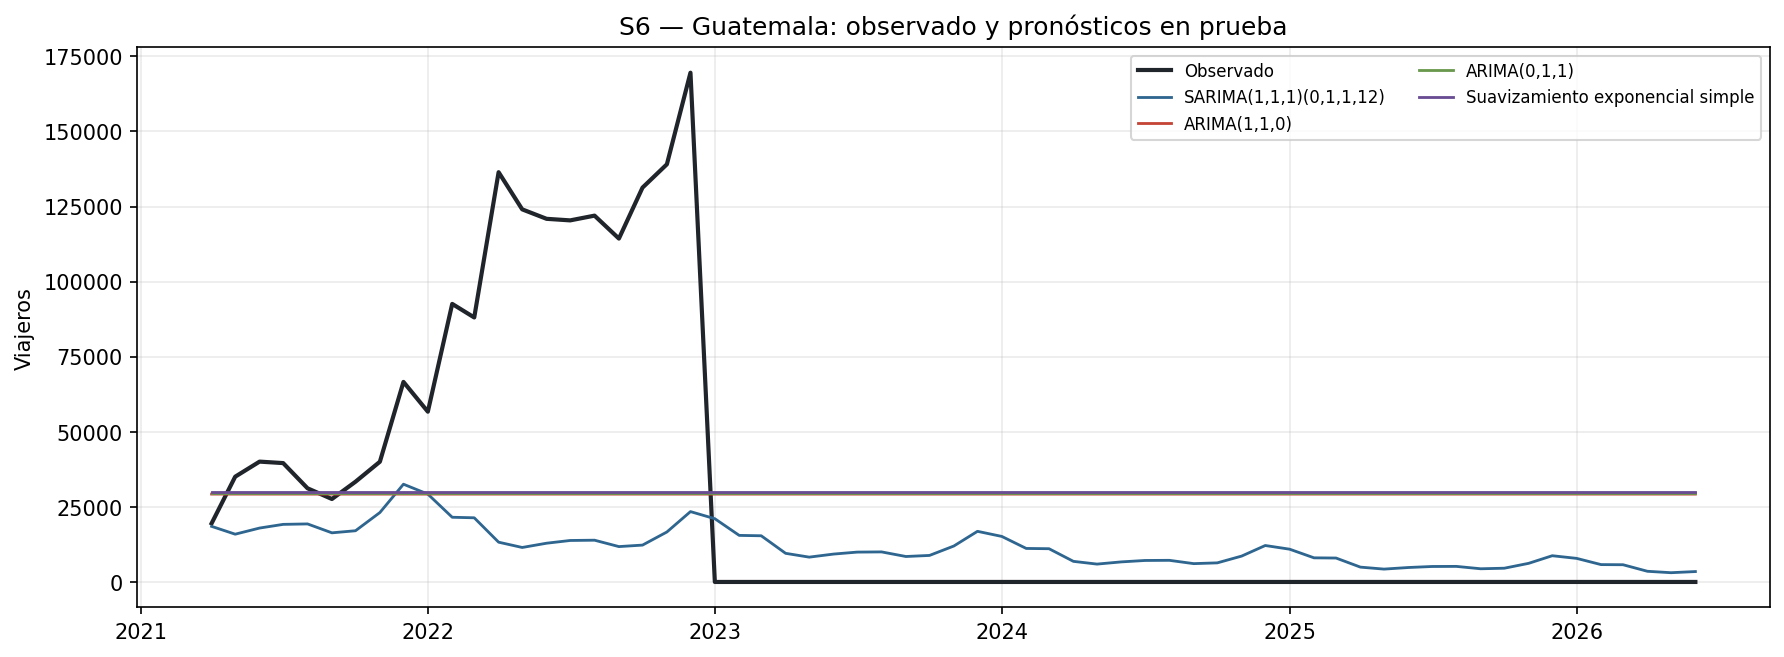

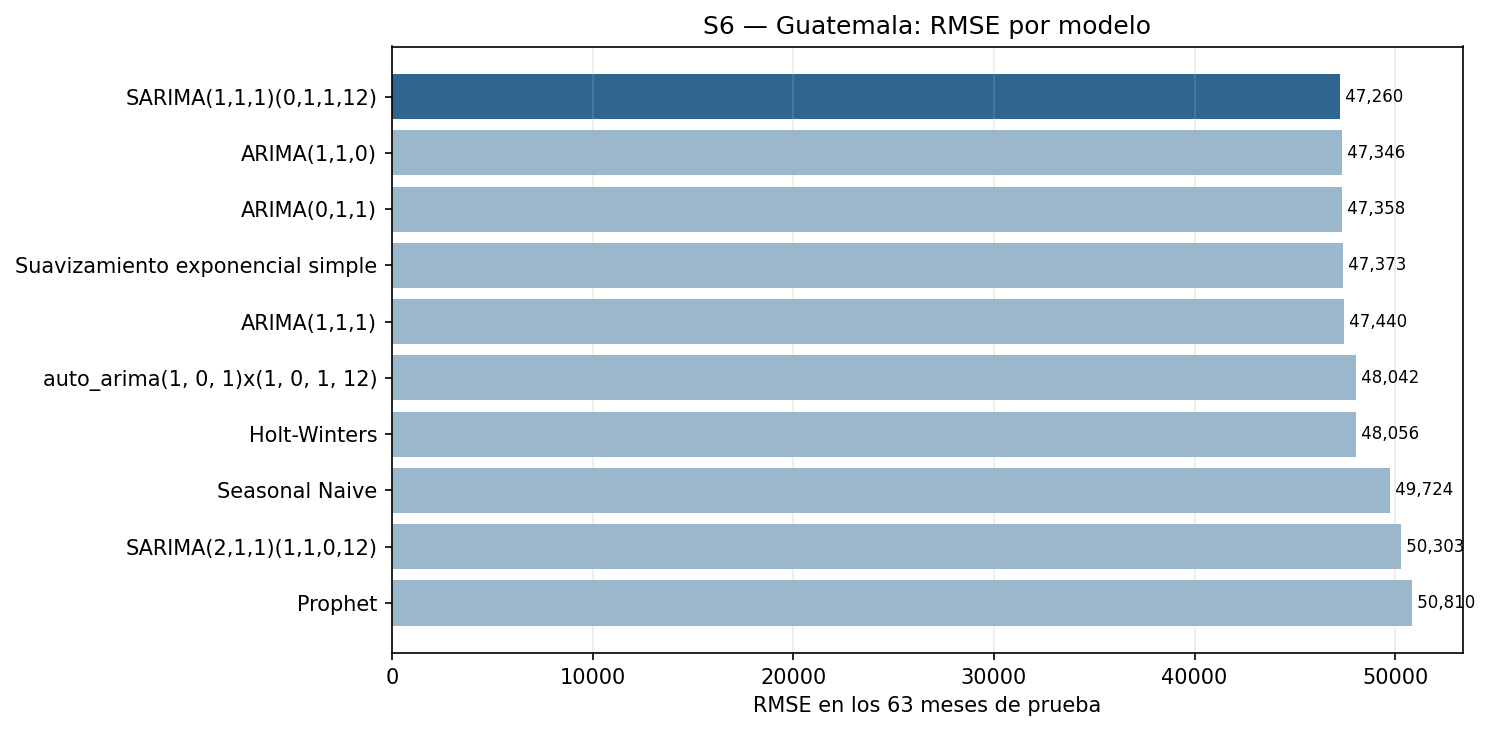

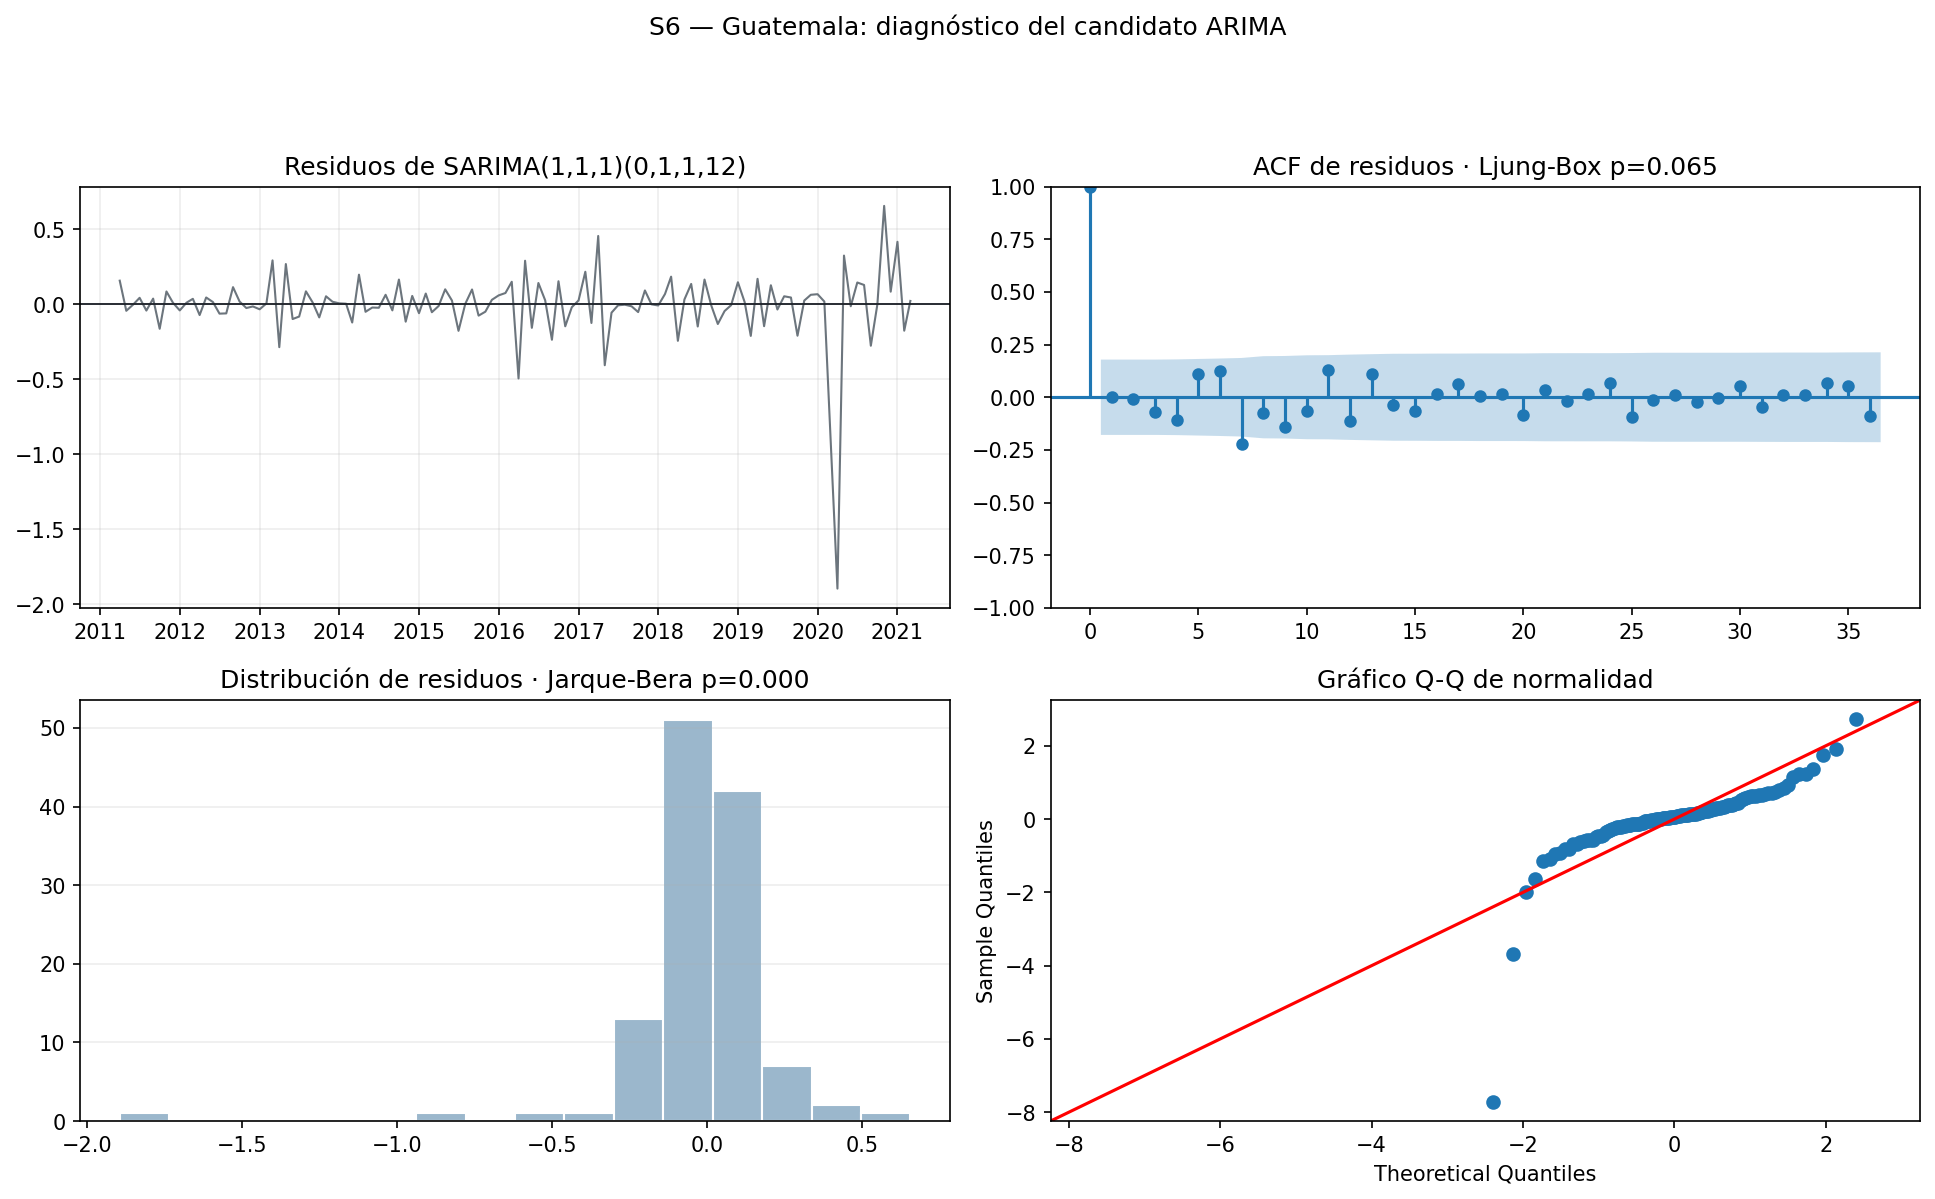

In [10]:
display(
    metricas.loc[
        metricas["serie"] == "S6_guatemala",
        [
            "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE",
            "Ljung_Box_p", "Jarque_Bera_p", "mejor_modelo",
        ],
    ].sort_values("RMSE").round(4)
)
display(Image(filename=str(DIR_IMG / "s6_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s6_rmse_modelos.png")))
display(Image(filename=str(DIR_IMG / "s6_residuos.png")))

SARIMA(1,1,1)(0,1,1,12) obtiene el menor RMSE (47,260) y Ljung-Box no
rechaza ruido blanco al 5% (`p=0.065`). El MAPE usa únicamente los 21 meses
de prueba distintos de cero: los 42 ceros metodológicos no deben interpretarse
como error porcentual de demanda turística.

## Comparación estadística de Países

Se emplean exactamente las métricas del comparativo de Fronteras: fuerza
estacional; pendiente y CAGR 2009–2019; coeficiente de variación y desviación
de log-diferencias; caída 2020 vs 2019 y meses de recuperación.

In [11]:
columnas = [
    "pais", "fuerza_estacional", "fuerza_tendencia",
    "pendiente_tendencia_relativa_pct_mes", "cagr_2009_2019_pct",
    "coeficiente_variacion_2009_2019",
    "desviacion_log_diferencias_2009_2019",
    "caida_2020_vs_2019_pct",
    "fecha_primera_recuperacion_mensual",
    "fecha_recuperacion_sostenida_media_movil_2019",
]
display(comparativo[columnas].round(4))

,pais,fuerza_estacional,fuerza_tendencia,pendiente_tendencia_relativa_pct_mes,cagr_2009_2019_pct,coeficiente_variacion_2009_2019,desviacion_log_diferencias_2009_2019,caida_2020_vs_2019_pct,fecha_primera_recuperacion_mensual,fecha_recuperacion_sostenida_media_movil_2019
0,El Salvador,0.4018,0.7828,0.8573,11.0722,0.4193,0.2981,79.7786,2022-12-01,2023-07-01
1,Estados Unidos,0.7044,0.7091,0.3536,4.5751,0.2974,0.3192,73.9908,2021-12-01,2023-01-01
2,Guatemala,0.5064,0.8404,0.8385,10.1021,0.3806,0.2139,70.1913,2022-12-01,NaT


### Respuestas

1. **Mayor estacionalidad: Estados Unidos** (0.704).
2. **Mayor crecimiento relativo: El Salvador**, con CAGR 11.07% y pendiente
   relativa mensual 0.857%; Guatemala queda cerca, pero no es turismo
   extranjero y pierde comparabilidad desde 2023.
3. **Mayor volatilidad mensual: Estados Unidos**, según log-diferencias
   (0.319). El Salvador tiene el mayor coeficiente de variación (0.419).
4. **Más afectado por la pandemia: El Salvador**, con caída de 79.78%.
   Estados Unidos recupera antes el promedio mensual y la media móvil de
   12 meses. Guatemala no alcanza recuperación sostenida antes de que el
   cambio de granularidad vuelva la serie individual incompleta.

## Tabla maestra S0–S6 y verificación de Prophet

In [12]:
mejores = tabla_maestra.loc[
    tabla_maestra["mejor_modelo"],
    ["serie", "modelo", "AIC", "BIC", "MAE", "RMSE", "MAPE"],
]
display(mejores.round(4))

cobertura_prophet = (
    tabla_maestra.loc[tabla_maestra["modelo"].eq("Prophet"), "serie"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)
print("Prophet ejecutado en:", ", ".join(cobertura_prophet))
assert len(cobertura_prophet) == 7

,serie,modelo,AIC,BIC,MAE,RMSE,MAPE
0,S0_total,Prophet,NaN,NaN,132304.3578,139548.6432,60.8874
8,S1_la_aurora,"ARIMA(1,1,1)",207.0270,215.9365,33049.4175,38249.0739,33.0811
17,S2_valle_nuevo,Prophet,NaN,NaN,16803.8514,23186.8219,157.6446
26,S3_san_cristobal,Prophet,NaN,NaN,7723.2948,10437.1069,146.8912
35,S4_el_salvador,Prophet,NaN,NaN,53080.9806,59455.0358,87.9178
45,S5_estados_unidos,"ARIMA(1,1,1)",431.9074,440.8168,22974.8341,26793.5240,47.0824
54,S6_guatemala,"SARIMA(1,1,1)(0,1,1,12)",13.4183,24.5683,27316.8366,47260.2458,66.2170


Prophet ejecutado en: S0_total, S1_la_aurora, S2_valle_nuevo, S3_san_cristobal, S4_el_salvador, S5_estados_unidos, S6_guatemala


## Conclusión del análisis de Países

S4–S6 quedaron analizadas con el mismo contrato de las cuatro series
anteriores. Estados Unidos es el mercado más estacional y volátil mes a mes;
El Salvador crecía más rápido y sufrió la mayor caída de 2020. Los resultados
de Guatemala son útiles hasta 2022, pero sus ceros posteriores son una
limitación de granularidad. Prophet corrió en las siete series y no fue
necesario activar un plan alternativo de instalación.